#### Import Raw POS Transaction Data

In [153]:
import pandas as pd
df = pd.read_csv("Sales Data November 2020 - October 2023.csv")


#### Data Review

In [154]:
df.head()

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
0,2854884835480,8725409595544,2020-11-11T01:39:33+03:00,TS1011,product,order,Online Store,Bathing & Skin Care,Mamia Sensitive Bathing & Skin Care 64 Bathing...,1,200.0,0.0,0,200.0,0,0.0,200.0
1,2864488448152,8752046604440,2020-11-16T16:43:01+03:00,TS1012,product,order,Point of Sale,Baby Formula,NANNYcare Growing Up Milk Goat Milk Based 3 Fr...,2,9000.0,0.0,0,9000.0,0,0.0,9000.0
2,2864491954328,8752055845016,2020-11-16T16:45:58+03:00,TS1013,product,order,Point of Sale,Baby Diapers,DryNites Spider-Man Baby & Toddler Clothing 16pk,1,1800.0,0.0,0,1800.0,0,0.0,1800.0
3,2864491954328,8752055877784,2020-11-16T16:45:58+03:00,TS1013,product,order,Point of Sale,Bathing & Skin Care,Metanium Nappy Rash Ointment 30g,1,1500.0,0.0,0,1500.0,0,0.0,1500.0
4,2864497066136,8752070656152,2020-11-16T16:49:47+03:00,TS1014,product,order,Point of Sale,Baby Formula,Aptamil 1 First Baby Milk Formula from Birth 800g,1,3000.0,0.0,0,3000.0,0,0.0,3000.0


In [155]:
df.shape

(28755, 17)

In [156]:
df.describe()

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
count,2.875500e+04,2.875500e+04,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000
mean,4.725462e+12,1.502482e+13,1.348392,2901.054775,-8.046427,-23.983551,2869.024798,9.871327,0.330354,2879.226479
std,6.424951e+11,2.100030e+12,1.327027,4470.603559,179.058569,487.065277,4486.248651,71.716823,15.286252,4480.645026
min,2.854885e+12,8.725410e+12,-12.000000,0.000000,-16200.000000,-38400.000000,-38400.000000,-800.000000,-112.000000,-38400.000000
25%,4.601180e+12,1.472930e+13,1.000000,420.000000,0.000000,0.000000,420.000000,0.000000,0.000000,450.000000
50%,4.953558e+12,1.584411e+13,1.000000,1500.000000,0.000000,0.000000,1500.000000,0.000000,0.000000,1500.000000
75%,5.182479e+12,1.648706e+13,1.000000,3300.000000,0.000000,0.000000,3300.000000,0.000000,0.000000,3300.000000
max,5.390480e+12,1.708426e+13,36.000000,102000.000000,0.000000,8500.000000,102000.000000,800.000000,1600.000000,102000.000000


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28755 entries, 0 to 28754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          28755 non-null  int64  
 1   Sale ID           28755 non-null  int64  
 2   Date              28755 non-null  object 
 3   Order             28755 non-null  object 
 4   Transaction type  28755 non-null  object 
 5   Sale type         28755 non-null  object 
 6   Sales channel     28755 non-null  object 
 7   Product type      17244 non-null  object 
 8   Product           27845 non-null  object 
 9   Net quantity      28755 non-null  int64  
 10  Gross sales       28755 non-null  float64
 11  Discounts         28755 non-null  float64
 12  Returns           28755 non-null  int64  
 13  Net sales         28755 non-null  float64
 14  Shipping          28755 non-null  int64  
 15  Taxes             28755 non-null  float64
 16  Total sales       28755 non-null  float6

In [158]:
#Check for Duplicated columns
df.duplicated().sum()

np.int64(0)

#### There are Null values present for Product type and Product columns.

In [159]:
# Check for null values
print("Missing values in each column:")
print(df.isna().sum())

Missing values in each column:
Order ID                0
Sale ID                 0
Date                    0
Order                   0
Transaction type        0
Sale type               0
Sales channel           0
Product type        11511
Product               910
Net quantity            0
Gross sales             0
Discounts               0
Returns                 0
Net sales               0
Shipping                0
Taxes                   0
Total sales             0
dtype: int64


In [160]:
#Number of unique values per column
print("Number of unique values per column:")
print(df.nunique())

Number of unique values per column:
Order ID            13257
Sale ID             28755
Date                13434
Order               13257
Transaction type        4
Sale type               2
Sales channel           3
Product type          100
Product              1923
Net quantity           30
Gross sales           296
Discounts              73
Returns                75
Net sales             405
Shipping               25
Taxes                  20
Total sales           419
dtype: int64


#### Data Cleaning

In [161]:
#Review Missing values to perform Data Cleaning
product_rows_missing = df[df['Product'].isna()]
display(product_rows_missing)   

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
19,2864990027928,8753513791640,2020-11-16T22:05:20+03:00,TS1020,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,300,0.0,300.0
106,2870444458136,8768868614296,2020-11-19T18:33:13+03:00,TS1053,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,300,0.0,300.0
141,2876307112088,8785404067992,2020-11-22T19:12:09+03:00,TS1072,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,400,0.0,400.0
142,2876366946456,8785575346328,2020-11-22T19:47:48+03:00,TS1073,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,300,0.0,300.0
171,2877662822552,8789176582296,2020-11-23T13:25:53+03:00,TS1082,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,400,0.0,400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28665,5388066226431,17076762870015,2023-10-29T09:40:07+03:00,TS14234,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,200,0.0,200.0
28696,5378025029887,17080704499967,2023-10-30T17:08:54+03:00,TS14092,shipping,return,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,-600,0.0,-600.0
28702,5389377896703,17080730288383,2023-10-30T17:17:10+03:00,TS14253,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,350,0.0,350.0
28713,5390051705087,17082845528319,2023-10-31T07:50:13+03:00,TS14256,shipping,order,Online Store,NaN,NaN,0,0.0,0.0,0,0.0,250,0.0,250.0


In [162]:
product_rows_missing.info()
product_rows_missing.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 910 entries, 19 to 28718
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          910 non-null    int64  
 1   Sale ID           910 non-null    int64  
 2   Date              910 non-null    object 
 3   Order             910 non-null    object 
 4   Transaction type  910 non-null    object 
 5   Sale type         910 non-null    object 
 6   Sales channel     910 non-null    object 
 7   Product type      0 non-null      object 
 8   Product           0 non-null      object 
 9   Net quantity      910 non-null    int64  
 10  Gross sales       910 non-null    float64
 11  Discounts         910 non-null    float64
 12  Returns           910 non-null    int64  
 13  Net sales         910 non-null    float64
 14  Shipping          910 non-null    int64  
 15  Taxes             910 non-null    float64
 16  Total sales       910 non-null    float64
dtyp

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
count,9.100000e+02,9.100000e+02,910.0,910.0,910.0,910.000000,910.000000,910.000000,910.0,910.000000
mean,4.848412e+12,1.542519e+13,0.0,0.0,0.0,71.974725,71.974725,311.923077,0.0,383.897802
std,5.725781e+11,1.849715e+12,0.0,0.0,0.0,610.066160,610.066160,261.486683,0.0,628.971743
min,2.864990e+12,8.753514e+12,0.0,0.0,0.0,0.000000,0.000000,-800.000000,0.0,-800.000000
25%,4.736789e+12,1.509612e+13,0.0,0.0,0.0,0.000000,0.000000,300.000000,0.0,300.000000
50%,5.060637e+12,1.614587e+13,0.0,0.0,0.0,0.000000,0.000000,300.000000,0.0,300.000000
75%,5.210016e+12,1.656516e+13,0.0,0.0,0.0,0.000000,0.000000,400.000000,0.0,400.000000
max,5.390149e+12,1.708325e+13,0.0,0.0,0.0,8500.000000,8500.000000,800.000000,0.0,8500.000000


#### Rows with missing product name have zero net sales. We will drop these

In [163]:
df.drop(product_rows_missing.index, inplace=True)

In [164]:
print(f"Missing values in 'Product' column after dropping: {df['Product'].isna().sum()}")

Missing values in 'Product' column after dropping: 0


In [165]:
df.isna().sum()

Order ID                0
Sale ID                 0
Date                    0
Order                   0
Transaction type        0
Sale type               0
Sales channel           0
Product type        10601
Product                 0
Net quantity            0
Gross sales             0
Discounts               0
Returns                 0
Net sales               0
Shipping                0
Taxes                   0
Total sales             0
dtype: int64

In [166]:
missing_product_type_rows = df[df['Product type'].isnull()]
display(missing_product_type_rows)


,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
7,2864504438936,8752091234456,2020-11-16T16:56:04+03:00,TS1015,product,order,Point of Sale,NaN,Rider,1,300.0,0.0,0,300.0,0,0.0,300.0
25,2865926504600,8756131233944,2020-11-17T12:26:52+03:00,TS1023,product,order,Point of Sale,NaN,Rider,1,150.0,0.0,0,150.0,0,24.0,174.0
35,2866079400088,8756561903768,2020-11-17T15:01:44+03:00,TS1026,product,order,Point of Sale,NaN,Rider,1,200.0,0.0,0,200.0,0,32.0,232.0
42,2866268700824,8757130330264,2020-11-17T17:36:38+03:00,TS1029,product,order,Point of Sale,NaN,Rider,1,240.0,0.0,0,240.0,0,0.0,240.0
45,2866358157464,8757400535192,2020-11-17T18:39:53+03:00,TS1031,product,order,Point of Sale,NaN,Rider,1,200.0,0.0,0,200.0,0,32.0,232.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28744,5390298022143,17083702837503,2023-10-31T14:47:51+03:00,TS14270,product,order,Point of Sale,NaN,Rider Swahili,1,150.0,0.0,0,150.0,0,0.0,150.0
28747,5390355464447,17083875328255,2023-10-31T16:05:55+03:00,TS14271,product,order,Point of Sale,NaN,Rider Swahili,1,530.0,0.0,0,530.0,0,0.0,530.0
28750,5390433911039,17084115648767,2023-10-31T17:36:00+03:00,TS14273,product,order,Point of Sale,NaN,Rider Peter,1,150.0,0.0,0,150.0,0,0.0,150.0
28752,5390478442751,17084252127487,2023-10-31T18:24:58+03:00,TS14274,product,order,Point of Sale,NaN,Rider Peter,1,450.0,0.0,0,450.0,0,0.0,450.0


In [167]:
missing_product_type_rows.info()
missing_product_type_rows.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 10601 entries, 7 to 28754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          10601 non-null  int64  
 1   Sale ID           10601 non-null  int64  
 2   Date              10601 non-null  object 
 3   Order             10601 non-null  object 
 4   Transaction type  10601 non-null  object 
 5   Sale type         10601 non-null  object 
 6   Sales channel     10601 non-null  object 
 7   Product type      0 non-null      object 
 8   Product           10601 non-null  object 
 9   Net quantity      10601 non-null  int64  
 10  Gross sales       10601 non-null  float64
 11  Discounts         10601 non-null  float64
 12  Returns           10601 non-null  int64  
 13  Net sales         10601 non-null  float64
 14  Shipping          10601 non-null  int64  
 15  Taxes             10601 non-null  float64
 16  Total sales       10601 non-null  float64
dty

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
count,1.060100e+04,1.060100e+04,10601.000000,10601.000000,10601.000000,10601.000000,10601.000000,10601.0,10601.000000,10601.000000
mean,4.499529e+12,1.428693e+13,1.200264,1417.791152,-15.847387,-12.922837,1389.020927,0.0,0.137479,1389.158406
std,7.605126e+11,2.508884e+12,1.022107,2901.437428,250.640493,320.396517,2836.468307,0.0,5.087201,2836.462605
min,2.864504e+12,8.752091e+12,-3.000000,0.000000,-16200.000000,-25000.000000,-25000.000000,0.0,-112.000000,-25000.000000
25%,3.931372e+12,1.254806e+13,1.000000,200.000000,0.000000,0.000000,200.000000,0.0,0.000000,200.000000
50%,4.788299e+12,1.524208e+13,1.000000,350.000000,0.000000,0.000000,350.000000,0.0,0.000000,350.000000
75%,5.128394e+12,1.633392e+13,1.000000,1500.000000,0.000000,0.000000,1500.000000,0.0,0.000000,1500.000000
max,5.390480e+12,1.708426e+13,36.000000,97200.000000,0.000000,0.000000,97200.000000,0.0,240.000000,97200.000000


In [168]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 27845 entries, 0 to 28754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          27845 non-null  int64  
 1   Sale ID           27845 non-null  int64  
 2   Date              27845 non-null  object 
 3   Order             27845 non-null  object 
 4   Transaction type  27845 non-null  object 
 5   Sale type         27845 non-null  object 
 6   Sales channel     27845 non-null  object 
 7   Product type      17244 non-null  object 
 8   Product           27845 non-null  object 
 9   Net quantity      27845 non-null  int64  
 10  Gross sales       27845 non-null  float64
 11  Discounts         27845 non-null  float64
 12  Returns           27845 non-null  int64  
 13  Net sales         27845 non-null  float64
 14  Shipping          27845 non-null  int64  
 15  Taxes             27845 non-null  float64
 16  Total sales       27845 non-null  float64
dty

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
count,2.784500e+04,2.784500e+04,27845.000000,27845.000000,27845.000000,27845.000000,27845.000000,27845.0,27845.000000,27845.000000
mean,4.721444e+12,1.501173e+13,1.392458,2995.863892,-8.309391,-27.119555,2960.434946,0.0,0.341151,2960.776096
std,6.442655e+11,2.106455e+12,1.325591,4511.700857,181.955044,482.208247,4528.576624,0.0,15.533919,4528.713426
min,2.854885e+12,8.725410e+12,-12.000000,0.000000,-16200.000000,-38400.000000,-38400.000000,0.0,-112.000000,-38400.000000
25%,4.598755e+12,1.472252e+13,1.000000,500.000000,0.000000,0.000000,500.000000,0.0,0.000000,500.000000
50%,4.949262e+12,1.583198e+13,1.000000,1700.000000,0.000000,0.000000,1700.000000,0.0,0.000000,1700.000000
75%,5.181385e+12,1.648396e+13,1.000000,3300.000000,0.000000,0.000000,3300.000000,0.0,0.000000,3300.000000
max,5.390480e+12,1.708426e+13,36.000000,102000.000000,0.000000,0.000000,102000.000000,0.0,1600.000000,102000.000000


In [169]:
print("Sales channel types:")
print(df['Sales channel'].value_counts())

Sales channel types:
Sales channel
Point of Sale    25679
Online Store      2161
Draft Orders         5
Name: count, dtype: int64


In [170]:
# Transaction-type unique values
print(df['Transaction type'].unique())
print(df['Transaction type'].value_counts())

['product' 'gift_card']
Transaction type
product      27843
gift_card        2
Name: count, dtype: int64


In [171]:
# Check Unique values in 'Sale type' column
print("Sale types:")
df['Sale type'].value_counts()

Sale types:


Sale type
order     27610
return      235
Name: count, dtype: int64

In [172]:
print("Product type counts (sorted from highest to lowest):")
display(df['Product type'].value_counts())

Product type counts (sorted from highest to lowest):


Product type
Baby Formula                          5727
Feeding and weaning                   4125
Bathing & Skin Care                   2474
Baby Diapers                          1341
Swim Nappies                           369
                                      ... 
Baby Walkers & Entertainers              1
Baby Activity Toys & Games & Gifts       1
Baby gift sets                           1
Baby stroller                            1
Baby Stroller                            1
Name: count, Length: 100, dtype: int64

In [173]:
print("Product counts (sorted from highest to lowest) - Top 20:")
display(df['Product'].value_counts().head(20))

Product counts (sorted from highest to lowest) - Top 20:


Product
Rider                                                                 1062
Rider Rajab                                                            849
Rider Peter                                                            791
Aptamil Stage 2 Follow On Milk Powder 800g                             715
Aptamil 2 Follow On Milk Powder 800G                                   619
Aptamil 1 First Baby Milk Formula from Birth 800g                      564
Rajab                                                                  527
Aptamil Stage 1 First Infant Milk Powder from Birth 800g               468
Peter                                                                  433
Rider Swahili                                                          423
NANNYcare 2 Follow On Milk Goat Milk Based From 6 Months 900g          331
NANNYcare Growing Up Milk Goat Milk Based 3 From 1 to 3 Years 900g     292
NANNYcare 1 Formula First Infant Goat Milk 900g - 0 â€“ 6 months       263
Aptamil 3 Growing

In [174]:
# As we are interested in Sales and not Returns, we will drop the rows with Sale Type Return
return_rows = df[df['Sale type'] == 'return']
return_rows.info()
return_rows.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 235 entries, 5 to 28706
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          235 non-null    int64  
 1   Sale ID           235 non-null    int64  
 2   Date              235 non-null    object 
 3   Order             235 non-null    object 
 4   Transaction type  235 non-null    object 
 5   Sale type         235 non-null    object 
 6   Sales channel     235 non-null    object 
 7   Product type      188 non-null    object 
 8   Product           235 non-null    object 
 9   Net quantity      235 non-null    int64  
 10  Gross sales       235 non-null    float64
 11  Discounts         235 non-null    float64
 12  Returns           235 non-null    int64  
 13  Net sales         235 non-null    float64
 14  Shipping          235 non-null    int64  
 15  Taxes             235 non-null    float64
 16  Total sales       235 non-null    float64
dtype

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
count,2.350000e+02,2.350000e+02,235.000000,235.0,235.0,235.000000,235.000000,235.0,235.000000,235.000000
mean,4.737212e+12,1.513570e+13,-1.255319,0.0,0.0,-3213.378723,-3213.378723,0.0,-0.476596,-3213.855319
std,7.280639e+11,2.292371e+12,1.110711,0.0,0.0,4169.658333,4169.658333,0.0,7.306074,4169.376215
min,2.864497e+12,8.752079e+12,-12.000000,0.0,0.0,-38400.000000,-38400.000000,0.0,-112.000000,-38400.000000
25%,4.600563e+12,1.479517e+13,-1.000000,0.0,0.0,-3500.000000,-3500.000000,0.0,0.000000,-3500.000000
50%,5.039949e+12,1.613599e+13,-1.000000,0.0,0.0,-2400.000000,-2400.000000,0.0,0.000000,-2400.000000
75%,5.220094e+12,1.659417e+13,-1.000000,0.0,0.0,-1200.000000,-1200.000000,0.0,0.000000,-1200.000000
max,5.386973e+12,1.708073e+13,-1.000000,0.0,0.0,-200.000000,-200.000000,0.0,0.000000,-200.000000


#### Drop Rows with Sale Type return

In [175]:
df.drop(return_rows.index, inplace=True)
print("Sale types after dropping returns:")
print(df['Sale type'].value_counts()) 

Sale types after dropping returns:
Sale type
order    27610
Name: count, dtype: int64


In [176]:
print("Number of unique values per column:")
for column in df.columns:
    print(f"- {column}: {df[column].nunique()} unique values")

Number of unique values per column:
- Order ID: 13257 unique values
- Sale ID: 27610 unique values
- Date: 13261 unique values
- Order: 13257 unique values
- Transaction type: 2 unique values
- Sale type: 1 unique values
- Sales channel: 3 unique values
- Product type: 100 unique values
- Product: 1923 unique values
- Net quantity: 21 unique values
- Gross sales: 296 unique values
- Discounts: 73 unique values
- Returns: 1 unique values
- Net sales: 344 unique values
- Shipping: 1 unique values
- Taxes: 19 unique values
- Total sales: 352 unique values


In [177]:
df.nunique()

Order ID            13257
Sale ID             27610
Date                13261
Order               13257
Transaction type        2
Sale type               1
Sales channel           3
Product type          100
Product              1923
Net quantity           21
Gross sales           296
Discounts              73
Returns                 1
Net sales             344
Shipping                1
Taxes                  19
Total sales           352
dtype: int64

In [178]:
zero_net_quantity_rows = df[df['Net quantity'] == 0]
display(zero_net_quantity_rows)
print(f"Number of rows with Net quantity = 0: {len(zero_net_quantity_rows)}")

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales


Number of rows with Net quantity = 0: 0


In [179]:
negative_net_quantity_rows = df[df['Net quantity'] < 0]
display(negative_net_quantity_rows)
print(f"Number of rows with Net quantity < 0: {len(negative_net_quantity_rows)}")

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales


Number of rows with Net quantity < 0: 0


In [180]:
print("DataFrame Info after cleaning:")
df.info()

print("\nDataFrame Description after cleaning:")
df.describe()

DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 27610 entries, 0 to 28754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          27610 non-null  int64  
 1   Sale ID           27610 non-null  int64  
 2   Date              27610 non-null  object 
 3   Order             27610 non-null  object 
 4   Transaction type  27610 non-null  object 
 5   Sale type         27610 non-null  object 
 6   Sales channel     27610 non-null  object 
 7   Product type      17056 non-null  object 
 8   Product           27610 non-null  object 
 9   Net quantity      27610 non-null  int64  
 10  Gross sales       27610 non-null  float64
 11  Discounts         27610 non-null  float64
 12  Returns           27610 non-null  int64  
 13  Net sales         27610 non-null  float64
 14  Shipping          27610 non-null  int64  
 15  Taxes             27610 non-null  float64
 16  Total sales   

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
count,2.761000e+04,2.761000e+04,27610.000000,27610.000000,27610.000000,27610.0,27610.000000,27610.0,27610.000000,27610.000000
mean,4.721310e+12,1.501068e+13,1.414995,3021.362914,-8.380116,0.0,3012.982798,0.0,0.348111,3013.330909
std,6.435186e+11,2.104816e+12,1.304419,4522.351138,182.726156,0.0,4495.332622,0.0,15.585197,4495.464186
min,2.854885e+12,8.725410e+12,1.000000,0.000000,-16200.000000,0.0,0.000000,0.0,0.000000,0.000000
25%,4.598741e+12,1.472248e+13,1.000000,500.000000,0.000000,0.0,500.000000,0.0,0.000000,500.000000
50%,4.948181e+12,1.582886e+13,1.000000,1700.000000,0.000000,0.0,1700.000000,0.0,0.000000,1700.000000
75%,5.181174e+12,1.648338e+13,1.000000,3400.000000,0.000000,0.0,3400.000000,0.0,0.000000,3400.000000
max,5.390480e+12,1.708426e+13,36.000000,102000.000000,0.000000,0.0,102000.000000,0.0,1600.000000,102000.000000


#### We need to review Product Types to be able to impute null values

In [181]:
unique_product_types = df['Product type'].unique()
print(f"Number of unique product types (including NaN): {len(unique_product_types)}")
print(f"Number of unique product types (excluding NaN): {df['Product type'].nunique()}")

print("\nAll unique Product Types with counts:")
for p_type, count in df['Product type'].value_counts().items():
    print(f"- {p_type}: {count}")

Number of unique product types (including NaN): 101
Number of unique product types (excluding NaN): 100

All unique Product Types with counts:
- Baby Formula: 5673
- Feeding and weaning: 4084
- Bathing & Skin Care: 2456
- Baby Diapers: 1333
- Swim Nappies: 362
- Feeding and weanings: 351
- Toys & Games & Gifts: 260
- Diaper Pants: 206
- Bottles & Bottling sets: 184
- Sterilising Tablets: 178
- Nappy Bags: 176
- Kids Toothpaste: 171
- Baby & Toddler Clothing: 151
- Safety & Wellness: 109
- Teething Soothers: 109
- Pull Ups: 102
- Maternity & nursing: 87
- Sterilising Fluid: 69
- Baby Toothbrush: 53
- Bibs: 50
- Changing Bag: 48
- Straw cup: 47
- Hair Styling Products: 45
- Chocolates: 43
- Backpacks: 39
- Lunch Boxes & Totes: 36
- Baby Baby & Toddler Clothing: 34
- Fabric Conditioner: 32
- Sterilising fluid: 28
- Sanitising Water: 28
- Gift Set: 26
- Candy & Chocolate: 26
- Nasal Aspirators: 25
- Nursery: 22
- Kids Multivitamins: 22
- Story & Novelty Books: 21
- Pen & Pencil Cases: 18
-

In [182]:
top_10_product_types = df['Product type'].value_counts().head(10).index.tolist()

print("Top 10 most frequent Product Types:")
for p_type in top_10_product_types:
    print(f"- {p_type}")

Top 10 most frequent Product Types:
- Baby Formula
- Feeding and weaning
- Bathing & Skin Care
- Baby Diapers
- Swim Nappies
- Feeding and weanings
- Toys & Games & Gifts
- Diaper Pants
- Bottles & Bottling sets
- Sterilising Tablets


In [183]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Order ID                0
Sale ID                 0
Date                    0
Order                   0
Transaction type        0
Sale type               0
Sales channel           0
Product type        10554
Product                 0
Net quantity            0
Gross sales             0
Discounts               0
Returns                 0
Net sales               0
Shipping                0
Taxes                   0
Total sales             0
dtype: int64


In [184]:
products_with_missing_type = df[df['Product type'].isnull()]
unique_products_missing_type = products_with_missing_type['Product'].unique()

print(f"Number of unique products with missing 'Product type': {len(unique_products_missing_type)}")

if len(unique_products_missing_type) > 0:
    print("Unique products with missing 'Product type':")
    for product in unique_products_missing_type:
        print(f"- {product}")
else:
    print("No products found with missing 'Product type'.")

Number of unique products with missing 'Product type': 651
Unique products with missing 'Product type':
- Rider
- Bus delivery
- Bus
- Fargo
- Aptamil Anti-Reflux
- Child's Farm Sensitive Bathing & Skin Care Unfragranced 250ml
- Aptamil 1 First Baby Milk Formula from Birth 800g
- Joie Mimzy Snacker Highchair-Numbers
- Tommee Tippee Basic Comfi Neck Catch All Bibs
- Rascal & Friends Essential Size 6 Nappies 30pk- 16+kgs
- Mamia Ultra Dry Size 6 Jumbo- 60 Nappies
- Little Angels Comfort & Protect Size 4+ Nappies - 78 pieces,9-20kg
- BeeGo Oven Safety Child Lock, 1 x Lock
- AYCORN Child & Baby Safety Proof Magnetic Cupboard Locks, 10 Locks & 2 Keys
- DryNites Spider-Man Baby & Toddler Clothing 16pk
- Mamia Ultra Dry Size 3 - 56 Nappies Weight: 4-9 kg / 9-20 lbs
- Aveeno Baby Daily Care Lotion 150Ml
- Little Angels Sensitive Baby 64 Wipes
- Little Angels Newborn Baby Dry Diapers Size 2 for Babies 3 - 6 kgs(60 Nappies)
- Aveeno Baby Hair and Body Wash 300ml
- Little Angels Comfort & Protect

In [185]:
# Review of product and Product type names indicate need to standardise the noisy data for easy data cleaning and missing values imputation
# Rows with product names related to rider, rider names and shipping services such as courier and bus companies will be dropped
rider_products = df[df['Product'].str.contains('rider', case=False, na=False)]
display(rider_products)
print(f"Number of rows with 'ride' in product name: {len(rider_products)}")

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
7,2864504438936,8752091234456,2020-11-16T16:56:04+03:00,TS1015,product,order,Point of Sale,NaN,Rider,1,300.0,0.0,0,300.0,0,0.0,300.0
25,2865926504600,8756131233944,2020-11-17T12:26:52+03:00,TS1023,product,order,Point of Sale,NaN,Rider,1,150.0,0.0,0,150.0,0,24.0,174.0
35,2866079400088,8756561903768,2020-11-17T15:01:44+03:00,TS1026,product,order,Point of Sale,NaN,Rider,1,200.0,0.0,0,200.0,0,32.0,232.0
42,2866268700824,8757130330264,2020-11-17T17:36:38+03:00,TS1029,product,order,Point of Sale,NaN,Rider,1,240.0,0.0,0,240.0,0,0.0,240.0
45,2866358157464,8757400535192,2020-11-17T18:39:53+03:00,TS1031,product,order,Point of Sale,NaN,Rider,1,200.0,0.0,0,200.0,0,32.0,232.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28741,5390271611135,17083623014655,2023-10-31T14:08:51+03:00,TS14269,product,order,Point of Sale,NaN,Rider,1,300.0,0.0,0,300.0,0,0.0,300.0
28744,5390298022143,17083702837503,2023-10-31T14:47:51+03:00,TS14270,product,order,Point of Sale,NaN,Rider Swahili,1,150.0,0.0,0,150.0,0,0.0,150.0
28747,5390355464447,17083875328255,2023-10-31T16:05:55+03:00,TS14271,product,order,Point of Sale,NaN,Rider Swahili,1,530.0,0.0,0,530.0,0,0.0,530.0
28750,5390433911039,17084115648767,2023-10-31T17:36:00+03:00,TS14273,product,order,Point of Sale,NaN,Rider Peter,1,150.0,0.0,0,150.0,0,0.0,150.0


Number of rows with 'ride' in product name: 4619


In [186]:
import re
import pandas as pd

# Transport keywords
TRANSPORT_KEYWORDS = [
    'bus', 'rider', 'coach', 'north rift', 'delivery to town', 'chania', 'modern coast', 'fargo', 'fago', 'courier', 'traveller','coast', 'metro', 'shuttle', 'sacco', 'exchange', 'super metro', 'guardian', 'driver', 'deliver'
]


# Normalize and deduplicate
TRANSPORT_KEYWORDS = list(set(k.lower() for k in TRANSPORT_KEYWORDS))

# Compile regex once (case-insensitive, word boundaries)
TRANSPORT_PATTERN = re.compile(
    r'\b(?:' + '|'.join(re.escape(k) for k in TRANSPORT_KEYWORDS) + r')\b',
    flags=re.IGNORECASE
)

# Function to check if row should be included

def check_row(product, ptype):
    if pd.isna(ptype) or str(ptype).strip() == '':
        product_str = str(product).strip()
        words = product_str.split()
        
        # Include if short or contains transport keyword
        if len(words)  < 3 or TRANSPORT_PATTERN.search(product_str):
            return True
        
    return False

# Filter products
matching_rows = df[df.apply(lambda row: check_row(row['Product'], row['Product type']), axis=1)]
products_to_check = df[df.apply(lambda row: check_row(row['Product'], row['Product type']), axis=1)]['Product'].unique()

# Display results
print(f"Number of products with missing 'Product type' containing specified keywords or single-word names: {len(products_to_check)}\n")
print(f"Total number of matching rows: {matching_rows.shape[0]}")

if len(products_to_check) > 0:
    print("Products with missing 'Product type' (single-word or containing keywords):")
    print('\n'.join(f"- {product}" for product in products_to_check))
else:
    print("No such products found with missing 'Product type'.")


Number of products with missing 'Product type' containing specified keywords or single-word names: 187

Total number of matching rows: 6875
Products with missing 'Product type' (single-word or containing keywords):
- Rider
- Bus delivery
- Bus
- Fargo
- Aptamil Anti-Reflux
- Nuby Teether
- LOL Backpack
- Custom sale
- WATER TEETHER
- Driver
- Delivery
- Delivery to Town
- Delivery to town
- Delivery to town by Karen
- Delivery to town by Jennifer
- G4s
- rider
- Delivery to Fargo
- Rider Rajab
- Rajab rider
- Deliveries
- Data rush
- Parcel
- Rider delivery to Town
- Rider (Rajab)
- Rider (Jeff)
- Ferrero Chocolate
- Rider (Kelvin)
- Fargo fee addition
- Rider(Jeff)
- rider (Jeff)
- Rajab Rider
- Jeff rider
- Rajab
- rider Rajab
- Bolt
- Rider.Rajab
- Rider (Jeff
- Rider Bolt(Joseph)
- Rider jeff
- Rider Jeff
- Rider bolt(George)
- rider Jeff
- Rider bolt
- Delivery (Rider Jeff )
- Delivery  Jeff
- Rider rajab
- Rider rajaab
- Modern coast
- rider Patrick
- Rider George
- rider george


In [187]:
import re

# Incorrect Product Names with delivery and transport related keyword
TRANSPORT_KEYWORDS = [
    'bus', 'rider', 'coach', 'north rift', 'delivery to town', 'chania', 'modern coast', 'fargo', 'fago', 'courier', 'traveller','coast', 'metro', 'shuttle', 'sacco', 'exchange', 'super metro', 'guardian', 'driver', 'deliver'
]

# Normalize and deduplicate
TRANSPORT_KEYWORDS = list(set(k.lower() for k in TRANSPORT_KEYWORDS))

# Compile regex once (case-insensitive, word boundaries)
TRANSPORT_PATTERN = re.compile(
    r'\b(?:' + '|'.join(re.escape(k) for k in TRANSPORT_KEYWORDS) + r')\b',
    flags=re.IGNORECASE
)

# Function to check if row should be included
def check_row(product, ptype):
    if pd.isna(ptype) or str(ptype).strip() == '':
        product_str = str(product).strip()
        words = product_str.split()
        
        
        # Include if short or contains transport keyword
        if len(words)  < 3 or TRANSPORT_PATTERN.search(product_str):
            return True
        
    return False

# Filter products
products_to_check = df[df.apply(lambda row: check_row(row['Product'], row['Product type']), axis=1)]['Product'].unique()

# Drop Identified product
# Identify indices to drop
indices_to_drop = df[
    (df['Product type'].isna() | (df['Product type'] == '')) &
    df['Product'].isin(products_to_check)
].index

df.drop(indices_to_drop, inplace=True)

print(f"Number of rows after dropping identified products: {df.shape[0]}")

# PRODUCT NAME CLEANING FUNCTION


def clean_product_name(product_name):
    name = str(product_name)

    # Basic normalization
    name = name.replace('&', 'and').lower()
    name = name.replace('(', '').replace(')', '')

    # Remove unwanted special characters (keep letters, numbers, spaces, hyphen)
    name = re.sub(r'[^a-z0-9\s-]', '', name)



    # Custom replacements
    replacements = {
        'angelcare': 'angel care',
        'organicbanana': 'organic banana',
        'bananaandstrawberry': 'banana and strawberry',
        'breakfastpeachy': 'breakfast peachy',
        'starter kit': 'starter set',
        'first baby': 'first infant',
        'from birth': '',
        'milk formula': 'milk powder',
        'wholesale price': '',
        'yrs': 'years',
    }

    for k, v in replacements.items():
        name = name.replace(k, v)

    # Aptamil standardization
    name = name.replace('aptamil organic stage', 'aptamil')
    name = name.replace('aptamil organic', 'aptamil')
    name = re.sub(r'aptamil\s+(\d+)', r'aptamil stage \1', name)
    if re.search(r'\baptamil\b', name):
        name = re.sub(r'\bgrowing up\b', 'toddler', name)
    if re.search(r'\baptamil\b', name):
        name = re.sub(r'\bfeeding and weaning\b', '', name)
    # Units normalization
    name = re.sub(r'(\d+)(g|ml)', r'\1 \2', name)
    name = re.sub(r'\bpk\b', 'pack', name)
    name = re.sub(r'\bmth\b', 'month', name)
    name = re.sub(r'\buk\b', '', name)
    name = re.sub(r'\bmax\b', 'maxi', name)
    name = re.sub(r'\bkg\b', 'kgs', name)

    # Convert ranges like 2 kg 5 kg → 2-5 kgs
    name = re.sub(
        r'(?i)\b(\d+(?:\.\d+)?)\s*kg[s]?\s*(?:-|to)?\s*(\d+(?:\.\d+)?)\s*kg[s]?\b',
        r'\1-\2 kgs',
        name
    )

    # Space between letters and numbers
    name = re.sub(r'(?<=\d)([a-z]+)', r' \1', name)
    name = re.sub(r'([a-z]+)(?=\d)', r'\1 ', name)

    # Clean hyphens between numbers
    name = re.sub(r'(?<=\d)\s*[-\s]\s*(?=\d)', '-', name)
    name = re.sub(r'(?<!\d)-(?!\d)', '', name)
    
    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name).strip()

    return name


# PRODUCT TYPE CLEANING FUNCTION


def clean_product_type(product_type):
    if pd.isna(product_type):
        return product_type
    pt = str(product_type).lower().strip()
    pt = pt.replace('&', 'and')
    pt = re.sub(r'[^a-z0-9\s]', '', pt)
    pt = re.sub(r'\s+', ' ', pt).strip()
    return pt



#  APPLY CLEANING


df['Product'] = df['Product'].apply(clean_product_name)
df['Product type'] = df['Product type'].apply(clean_product_type)





Number of rows after dropping identified products: 20735


In [188]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Order ID               0
Sale ID                0
Date                   0
Order                  0
Transaction type       0
Sale type              0
Sales channel          0
Product type        3679
Product                0
Net quantity           0
Gross sales            0
Discounts              0
Returns                0
Net sales              0
Shipping               0
Taxes                  0
Total sales            0
dtype: int64


In [189]:
df['Product type'].fillna('Unknown', inplace=True)
print(f"Missing values in 'Product type' after filling: {df['Product type'].isnull().sum()}")
unknown_product_type_products = df[df['Product type'] == 'Unknown']['Product'].unique()

print(f"Number of unique products with 'Unknown' Product type: {len(unknown_product_type_products)}")

if len(unknown_product_type_products) > 0:
    print("Unique products with 'Unknown' Product type:")
    for product in unknown_product_type_products:
        print(f"- {product}")
else:
    print("No products found with 'Unknown' Product type.")

Missing values in 'Product type' after filling: 0
Number of unique products with 'Unknown' Product type: 459
Unique products with 'Unknown' Product type:
- childs farm sensitive bathing and skin care unfragranced 250 ml
- aptamil stage 1 first infant milk powder 800 g
- joie mimzy snacker highchairnumbers
- tommee tippee basic comfi neck catch all bibs
- rascal and friends essential size 6 nappies 30 pk 16 kgs
- mamia ultra dry size 6 jumbo 60 nappies
- little angels comfort and protect size 4 nappies 78 pieces 9-20 kg
- beego oven safety child lock 1 x lock
- aycorn child and baby safety proof magnetic cupboard locks 10 locks and 2 keys
- drynites spiderman baby and toddler clothing 16 pk
- mamia ultra dry size 3-56 nappies weight 4-9 kgs 9-20 lbs
- aveeno baby daily care lotion 150 ml
- little angels sensitive baby 64 wipes
- little angels newborn baby dry diapers size 2 for babies 3-6 kgs 60 nappies
- aveeno baby hair and body wash 300 ml
- little angels comfort and protect size 6 n

C:\Users\eerkmem\AppData\Local\Temp\ipykernel_21032\550577594.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product type'].fillna('Unknown', inplace=True)


In [190]:
product_reclassification_suggestions = {}

# create a mapping of keywords to product types for more robust matching
# this also handles variations and ensures more relevant suggestions
product_type_keywords = {
    'baby formula': ['formula', 'milk', 'follow on', 'growing up', 'aptamil', 'nannycare', 'hipp organic', 'kendamil', 'sma', 'cow and gate'],
    'feeding and weaning': ['feeding', 'weaning', 'cup', 'bottle', 'porridge', 'cereal', 'banana', 'muesli', 'spoon', 'bowl', 'highchair', 'sippy', 'teat', 'blender', 'steriliser', 'pump', 'food maker', 'rusks', 'biscotti', 'pouch', 'plate', 'mug', 'jar', 'feeder', 'masher', 'bottle warmer', 'milk powder dispenser', 'straw cup'],
    'bathing and skin care': ['bathing', 'skin care', 'wipes', 'lotion', 'wash', 'cream', 'ointment', 'shampoo', 'oil', 'spf', 'sun cream', 'sun lotion', 'moisturising', 'soap', 'bath additive', 'eczema', 'nappy cream', 'talc', 'sponge', 'rinser', 'bubble bath', 'conditioner', 'body wash', 'gel'],
    'baby diapers': ['nappies', 'diaper', 'nappy pants', 'pull ups', 'drynites', 'mamia', 'huggies', 'rascal and friends', 'little angels', 'fred and flo', 'lupilu', 'pampers'],
    'swim nappies': ['swim nappies', 'splashers', 'little swimmers'],
    'toys and games and gifts': ['toy', 'game', 'party', 'gift','swing', 'bloks', 'lego', 'vtech', 'fisher-price', 'mega bloks', 'play-doh', 'crayola', 'puzzle', 'activity', 'playmat', 'fidget', 'board game', 'soft toy', 'stuffed animal', 'scooter'],
    'sterilising tablets': ['sterilising tablets', 'milton sterilising', 'steriliser', 'sterilising fluid'],
    'bottles and bottling sets': ['bottle', 'bottling sets', 'avent', 'tommee tippee', 'mam', 'nuk', 'dr. brown'],
    'safety and wellness': ['safety', 'monitor', 'pressure', 'lamp', 'thermometer', 'nasal aspirator', 'grooming', 'medicine', 'first aid', 'gate', 'lock', 'socket covers', 'corner cushions', 'humidifier'],
    'baby and toddler clothing': ['clothing', 'shoe', 'dungaree', 'dress', 'leather', 'shirt', 'legging', 'cap', 'shorts', 'pyjamas', 'boots', 'sweater', 'towel', 'cap' , 'pants', 'romper', 'bodysuit', 'pajamas', 'pjs', 'swimsuit', 'socks', 'tights', 'hat', 'gloves', 'cardigan', 'set', 'jacket', 't-shirt', 'all-in-one', 'bloomers', 'outfit', 'dungaaree', 'skirt'],
    'nappy bags': ['nappy bags', 'diaper disposal', 'nappy sacks'],
    'maternity and nursing': ['maternity', 'nursing', 'breast pump', 'breast pads', 'nipple cream', 'bra', 'briefs'],
    'baby carrier and accessories': ['baby carrier', 'hipseat'],
    'high chairs and booster seats': ['highchair', 'booster seat'],
    'car seat': ['car seat'],
    'nursery': ['nursery', 'cot', 'crib', 'sleeping bag', 'bedding', 'blanket', 'playmat', 'mobile', 'thermometer'],
    'backpacks': ['backpack', 'bag'],
    'lunch boxes and totes': ['lunch box', 'tote', 'food flask'],
    'kids toothpaste': ['toothpaste', 'toothbrush', 'oral-b', 'colgate', 'aquafresh'],
    'kids multivitamins': ['multivitamins'],
    'baby sleeping bag': ['sleeping bag'],
    'baby monitor': ['baby monitor'],
    'baby baby and toddler clothing': ['baby clothing', 'suit', 'leggings', 'sandals', ' denim','toddler clothing'],
    'breast pump': ['breast pump', 'medela', 'lansinoh'],
    'baby toothbrush': ['toothbrush'],
    'sterilising fluid': ['sterilising fluid'],
    'nipple cream': ['nipple cream'],
    'baby bedding': ['bedding', 'sheets', 'blanket'],
    'potty training': ['potty training', 'potty'],
    'bowls': ['bowl'],
    'teething soothers': ['teether', 'teething soother', 'teethe'],
    'laundry equipment': ['laundry', 'detergent', 'rack'],
    'baby nappies': ['nappies', 'diapers'],
    'bibs': ['bibs'],
    'fabric conditioner': ['fabric conditioner'],
    'sanitising water': ['sanitising water', 'hand sanitiser'],
    'sterilising fluid': ['sterilising fluid'],
    'milk storage bags': ['milk storage bags', 'storage bags'],
    'tooth brush': ['toothbrush'],
    'straw cup': ['straw cup'],
    'pull ups': ['pull ups', 'trainer'],
    'diaper pants': ['diaper pants', 'nappy pants'],
    'baby potties': ['potty'],
    'play tent': ['play tent'],
    'electric steriliser': ['electric steriliser'],
    'bed mats': ['bed mat', 'bed mats', 'mat'],
    'electric toothbrush': ['electric toothbrush'],
    'chocolates': ['chocolate', 'cadbury'],
    'popper fidget': ['fidget'],
    'diaper disposal refills': ['diaper disposal refills', 'sangenic', 'nappy disposal'],
    'dining set': ['dining set'],
    'kids mask': ['kids mask'],
    'hair styling products': ['hair styling products', 'shampoo', 'conditioner', 'leave-in conditioner'],
    'walkers': ['walker'],
    'no -touch thermometer': ['thermometer'],
    'gift set': ['gift set'],
    'kids scooters': ['scooter'],
    'baby teething soothers': ['teether', 'teething soother'],
    'pen and pencil cases': ['pencil case', 'pen case'],
    'kids sports bottle': ['sports bottle', 'bottle'],
    'hand sanitiser': ['hand sanitiser'],
    'nasal aspirators': ['nasal aspirator', 'nasal spray'],
    'odour spray': ['odour spray'],
    'story and novelty books': ['story book', 'novelty book', 'book'],
    'vapopads refills': ['vapopads refills'],
    'kids tablet': ['kids tablet', 'tablet'],
    'candy and chocolate': ['candy', 'chocolate'],
    'colouring book': ['colouring book'],
    'sleeping aids': ['sleeping aids'],
    'nipple shield': ['nipple shield'],
    'baby gift sets': ['baby gift set', 'gift set'],
    'baby health and grooming kits': ['health kit', 'grooming kit'],
    'laundry detergent': ['laundry detergent', 'detergent'],
    'changing bag': ['changing bag'],
    'socks': ['sock'],
    'formula storage box': ['formula storage box'],
    'suitcases': ['suitcase'],
    'bathtubs': ['bathtub'],
    'baby health and grooming kits and grooming kits': ['health kit', 'grooming kit'],
    'baby safety locks and guards': ['safety lock', 'guard', 'latch'],
    'washcloth': ['washcloth', 'hooded'],
    'laundry bag': ['laundry bag'],
    'tommee tippee breast pads': ['breast pads'],
    'milk powder dispenser': ['milk powder dispenser'],
    'baby teething soothers': ['teething soother', 'teether'],
    'baby walkers and entertainers': ['walker', 'entertainer', 'dreamer'],
    'reusable nappies': ['reusable nappies'],
    'baby activity toys and games and gifts': ['activity toy', 'patrol', 'car', 'toy', 'game', 'gift'],
    'baby gift sets': ['baby gift set', 'gift set'],
    'baby stroller': ['stroller', 'pram'],
    'nipple cream': ['nipple cream'],
    'height measurement sticker': ['height measurement sticker']
}

# group keywords by their normalized product type to handle variations and overlaps
# Group keywords by their normalized product type to handle variations and overlaps
normalized_keywords_map = {}
for p_type, keywords_list in product_type_keywords.items():
    # Normalize the product type for consistent lookup
    normalized_p_type = p_type.strip().replace(' & ', ' and ').replace(' & ', ' and ').replace('  ', ' ')
    for keyword in keywords_list:
        if keyword not in normalized_keywords_map:
            normalized_keywords_map[keyword] = set()
        normalized_keywords_map[keyword].add(normalized_p_type)

for unknown_product in unknown_product_type_products:
    product_name_lower = str(unknown_product).lower()
    suggestions = set()

    # check if any keyword associated with a known product type is present in the unknown product's name
    for keyword, associated_types in normalized_keywords_map.items():
        if keyword in product_name_lower:
            suggestions.update(associated_types)

    if suggestions:
        product_reclassification_suggestions[unknown_product] = sorted(list(suggestions))

print("reclassification suggestions for 'unknown' products:")
for product, suggestions in product_reclassification_suggestions.items():
    print(f"- {product}: {', '.join(suggestions)}")

reclassification suggestions for 'unknown' products:
- childs farm sensitive bathing and skin care unfragranced 250 ml: baby activity toys and games and gifts, bathing and skin care
- aptamil stage 1 first infant milk powder 800 g: baby formula
- joie mimzy snacker highchairnumbers: feeding and weaning, high chairs and booster seats
- tommee tippee basic comfi neck catch all bibs: bibs, bottles and bottling sets
- rascal and friends essential size 6 nappies 30 pk 16 kgs: baby diapers, baby nappies
- mamia ultra dry size 6 jumbo 60 nappies: baby diapers, baby nappies, bottles and bottling sets
- little angels comfort and protect size 4 nappies 78 pieces 9-20 kg: baby diapers, baby nappies, bathing and skin care
- beego oven safety child lock 1 x lock: safety and wellness
- aycorn child and baby safety proof magnetic cupboard locks 10 locks and 2 keys: feeding and weaning, safety and wellness
- drynites spiderman baby and toddler clothing 16 pk: baby and toddler clothing, baby baby and t

In [191]:
for product, suggestions in product_reclassification_suggestions.items():
    if suggestions:
        # Assuming the first suggestion is the most appropriate if multiple exist
        new_product_type = suggestions[0]
        # Update only rows where product type is 'Unknown' for this product
        df.loc[(df['Product'] == product) & (df['Product type'] == 'Unknown'), 'Product type'] = new_product_type

print("Reclassification applied. Checking remaining 'Unknown' product types:")
remaining_unknown = df[df['Product type'] == 'Unknown']['Product'].nunique()
print(f"Number of unique products with 'Unknown' Product type remaining: {remaining_unknown}")

Reclassification applied. Checking remaining 'Unknown' product types:
Number of unique products with 'Unknown' Product type remaining: 0


In [192]:
df['Product type'].value_counts(dropna=False)



Product type
baby formula                              7118
feeding and weaning                       4158
bathing and skin care                     2660
baby diapers                              1961
baby activity toys and games and gifts     574
                                          ... 
bathtubs                                     2
toys and games and gifts and games           1
washcloth                                    1
laundry bag                                  1
tommee tippee breast pads                    1
Name: count, Length: 91, dtype: int64

In [193]:
# Filter rows where Product type is missing
missing_type_rows = df[df['Product type'].isna() | (df['Product type'] == '')]

# Aggregate Net quantity per unique product
missing_products_summary = (
    missing_type_rows.groupby('Product')['Net quantity']
    .sum()
    .sort_values(ascending=False)
)

# Display all products with Net quantity > 0
print("Products with missing Product type:")
display(missing_products_summary[missing_products_summary > 0])


Products with missing Product type:


Series([], Name: Net quantity, dtype: int64)

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20735 entries, 0 to 28753
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          20735 non-null  int64  
 1   Sale ID           20735 non-null  int64  
 2   Date              20735 non-null  object 
 3   Order             20735 non-null  object 
 4   Transaction type  20735 non-null  object 
 5   Sale type         20735 non-null  object 
 6   Sales channel     20735 non-null  object 
 7   Product type      20735 non-null  object 
 8   Product           20735 non-null  object 
 9   Net quantity      20735 non-null  int64  
 10  Gross sales       20735 non-null  float64
 11  Discounts         20735 non-null  float64
 12  Returns           20735 non-null  int64  
 13  Net sales         20735 non-null  float64
 14  Shipping          20735 non-null  int64  
 15  Taxes             20735 non-null  float64
 16  Total sales       20735 non-null  float64
dty

In [195]:
df.isna().sum()

Order ID            0
Sale ID             0
Date                0
Order               0
Transaction type    0
Sale type           0
Sales channel       0
Product type        0
Product             0
Net quantity        0
Gross sales         0
Discounts           0
Returns             0
Net sales           0
Shipping            0
Taxes               0
Total sales         0
dtype: int64

In [196]:
df.duplicated().sum()

np.int64(0)

In [197]:
df.head()

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
0,2854884835480,8725409595544,2020-11-11T01:39:33+03:00,TS1011,product,order,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,0,200.0,0,0.0,200.0
1,2864488448152,8752046604440,2020-11-16T16:43:01+03:00,TS1012,product,order,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,0,9000.0,0,0.0,9000.0
2,2864491954328,8752055845016,2020-11-16T16:45:58+03:00,TS1013,product,order,Point of Sale,baby diapers,drynites spiderman baby and toddler clothing 1...,1,1800.0,0.0,0,1800.0,0,0.0,1800.0
3,2864491954328,8752055877784,2020-11-16T16:45:58+03:00,TS1013,product,order,Point of Sale,bathing and skin care,metanium nappy rash ointment 30 g,1,1500.0,0.0,0,1500.0,0,0.0,1500.0
4,2864497066136,8752070656152,2020-11-16T16:49:47+03:00,TS1014,product,order,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,0,3000.0,0,0.0,3000.0


In [198]:
aptamil_product_sales = df[df['Product'].str.contains('aptamil', case=False, na=False)].groupby('Product')['Net quantity'].sum().sort_values(ascending=False)
pd.set_option('display.max_rows', None)
display(aptamil_product_sales)
pd.reset_option('display.max_rows')

Product
aptamil stage 2 follow on milk powder 800 g                               2963
aptamil stage 1 first infant milk powder 800 g                            2266
aptamil stage 3 toddler milk powder 800 g                                  834
aptamil creamed banana 125 g                                               310
aptamil creamed porridge 4 month plus 125 g                                259
aptamil baby rice 4 month 125 g                                            247
aptamil multigrain banana and berry cereal for 7 months babies 200 gms     242
aptamil lactose free milk powder 400 g                                     186
aptamil multigrain cereal 200 g 7 month plus                               171
aptamil oats raisin and apple bircher muesli 275 g                         165
aptamil comfort baby milk powder 800 g                                     157
aptamil stage 4 from 2 to 3 years 800 gm                                   126
aptamil banana and strawberry porridge 6 mon

#### Purposive Sampling : We will Sample the top products with high Number of transactions

In [199]:
df_copy = df

In [200]:
df_copy.shape

(20735, 17)

In [201]:

pd.set_option('display.max_rows', None) # Set option to display all rows
product_type_orders = df.groupby('Product type')['Sale ID'].nunique().sort_values(ascending=False)
product_type_orders
pd.reset_option('display.max_rows') # Reset option to default after display

In [202]:
product_sales_above_250 = df.groupby('Product')['Net quantity'].sum()
product_sales_above_250 = product_sales_above_250[product_sales_above_250 > 250].sort_values(ascending=False)
df_top_products = product_sales_above_250.reset_index()
df_top_products.columns = ['Product', 'Total Net Quantity']
display(df_top_products)

,Product,Total Net Quantity
0,aptamil stage 2 follow on milk powder 800 g,2963
1,aptamil stage 1 first infant milk powder 800 g,2266
2,aptamil stage 3 toddler milk powder 800 g,834
3,mamia sensitive bathing and skin care 64 bathi...,777
4,nannycare 2 follow on milk goat milk based fro...,766
5,waterwipes bathing and skin care sensitive new...,662
6,nannycare growing up milk goat milk based 3 fr...,638
7,nannycare 1 formula first infant goat milk 900...,533
8,cow and gate creamy porridge 4-6 months 125 g,347
9,hipp organic combiotic follow on milk 800 g,343


In [203]:
df_filtered_top_products = df[df['Product'].isin(df_top_products['Product'])]
display(df_filtered_top_products.head())

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
0,2854884835480,8725409595544,2020-11-11T01:39:33+03:00,TS1011,product,order,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,0,200.0,0,0.0,200.0
1,2864488448152,8752046604440,2020-11-16T16:43:01+03:00,TS1012,product,order,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,0,9000.0,0,0.0,9000.0
4,2864497066136,8752070656152,2020-11-16T16:49:47+03:00,TS1014,product,order,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,0,3000.0,0,0.0,3000.0
6,2864504438936,8752091201688,2020-11-16T16:56:04+03:00,TS1015,product,order,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,0,3000.0,0,0.0,3000.0
8,2864509321368,8752103653528,2020-11-16T16:59:30+03:00,TS1016,product,order,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,0,3000.0,0,0.0,3000.0


In [204]:
df.nunique()

Order ID            13141
Sale ID             20735
Date                13145
Order               13141
Transaction type        2
Sale type               1
Sales channel           3
Product type           91
Product              1688
Net quantity           21
Gross sales           245
Discounts              61
Returns                 1
Net sales             281
Shipping                1
Taxes                  12
Total sales           284
dtype: int64

In [205]:
df_filtered_top_products.shape

(5853, 17)

In [206]:
df = df_filtered_top_products

In [207]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 5853 entries, 0 to 28751
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          5853 non-null   int64  
 1   Sale ID           5853 non-null   int64  
 2   Date              5853 non-null   object 
 3   Order             5853 non-null   object 
 4   Transaction type  5853 non-null   object 
 5   Sale type         5853 non-null   object 
 6   Sales channel     5853 non-null   object 
 7   Product type      5853 non-null   object 
 8   Product           5853 non-null   object 
 9   Net quantity      5853 non-null   int64  
 10  Gross sales       5853 non-null   float64
 11  Discounts         5853 non-null   float64
 12  Returns           5853 non-null   int64  
 13  Net sales         5853 non-null   float64
 14  Shipping          5853 non-null   int64  
 15  Taxes             5853 non-null   float64
 16  Total sales       5853 non-null   float64
dtyp

Order ID            0
Sale ID             0
Date                0
Order               0
Transaction type    0
Sale type           0
Sales channel       0
Product type        0
Product             0
Net quantity        0
Gross sales         0
Discounts           0
Returns             0
Net sales           0
Shipping            0
Taxes               0
Total sales         0
dtype: int64

#### Feature Engineering

In [208]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Weekday'] = df['Date'].dt.day_name()

C:\Users\eerkmem\AppData\Local\Temp\ipykernel_21032\883953853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\eerkmem\AppData\Local\Temp\ipykernel_21032\883953853.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month
C:\Users\eerkmem\AppData\Local\Temp\ipykernel_21032\883953853.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [209]:
df.loc[:, 'Sale ID'] = df['Sale ID'].astype(str)
df.loc[:, 'Order ID'] = df['Order ID'].astype(str)

print(" 'Sale ID' and 'Order ID' columns have been converted to string type.")

 'Sale ID' and 'Order ID' columns have been converted to string type.


C:\Users\eerkmem\AppData\Local\Temp\ipykernel_21032\153365086.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['8725409595544' '8752046604440' '8752070656152' ... '17083875262719'
 '17084115615999' '17084252094719']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Sale ID'] = df['Sale ID'].astype(str)
C:\Users\eerkmem\AppData\Local\Temp\ipykernel_21032\153365086.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['2854884835480' '2864488448152' '2864497066136' ... '5390355464447'
 '5390433911039' '5390478442751']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Order ID'] = df['Order ID'].astype(str)


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5853 entries, 0 to 28751
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype                    
---  ------            --------------  -----                    
 0   Order ID          5853 non-null   object                   
 1   Sale ID           5853 non-null   object                   
 2   Date              5853 non-null   datetime64[ns, UTC+03:00]
 3   Order             5853 non-null   object                   
 4   Transaction type  5853 non-null   object                   
 5   Sale type         5853 non-null   object                   
 6   Sales channel     5853 non-null   object                   
 7   Product type      5853 non-null   object                   
 8   Product           5853 non-null   object                   
 9   Net quantity      5853 non-null   int64                    
 10  Gross sales       5853 non-null   float64                  
 11  Discounts         5853 non-null   float64      

In [211]:
df.nunique()

Order ID            5483
Sale ID             5853
Date                5482
Order               5483
Transaction type       1
Sale type              1
Sales channel          2
Product type           5
Product               17
Net quantity          19
Gross sales          134
Discounts             38
Returns                1
Net sales            155
Shipping               1
Taxes                  1
Total sales          155
Month                 12
Year                   4
Weekday                7
dtype: int64

In [212]:
print('Unique values for Returns:', df['Returns'].unique())
print('Unique values for Year:', df['Year'].unique())
print('Unique values for Weekday:', df['Weekday'].unique())
print('Unique values for Shipping:', df['Shipping'].unique())
print('Unique values for Sales channel:', df['Sales channel'].unique())
print('Unique values for Sale type:', df['Sale type'].unique())
print('Unique values for Transaction type:', df['Transaction type'].unique())
print('Unique values for Taxes:', df['Taxes'].unique())

Unique values for Returns: [0]
Unique values for Year: [2020 2021 2022 2023]
Unique values for Weekday: ['Wednesday' 'Monday' 'Tuesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
Unique values for Shipping: [0]
Unique values for Sales channel: ['Online Store' 'Point of Sale']
Unique values for Sale type: ['order']
Unique values for Transaction type: ['product']
Unique values for Taxes: [0.]


In [213]:
# We will drop the columns "Returns, Shipping, Sale type and Transaction Type" as they only have one value

df = df.drop('Returns', axis=1)
df = df.drop('Shipping', axis=1)
df = df.drop('Sale type', axis=1)
df = df.drop('Transaction type', axis=1)

# We will drop taxes column as it is not required for modelling
df = df.drop('Taxes', axis=1)
# we will drop Order column is unique for each order_id hence redundant
df = df.drop('Order', axis=1)



In [214]:
df.loc[:, 'Sale ID'] = df['Sale ID'].astype(str)
df.loc[:, 'Order ID'] = df['Order ID'].astype(str)

print(" 'Sale ID' and 'Order ID' columns have been converted to string type.")

 'Sale ID' and 'Order ID' columns have been converted to string type.


In [215]:
df['unit_price'] = df['Net sales'] / df['Net quantity']

In [216]:
df.loc[:, 'Discounts'] = df['Discounts'].abs()

In [217]:
df.loc[:, 'Discount_Percentage'] = (df['Discounts'] / df['Gross sales']) * 100

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5853 entries, 0 to 28751
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   Order ID             5853 non-null   object                   
 1   Sale ID              5853 non-null   object                   
 2   Date                 5853 non-null   datetime64[ns, UTC+03:00]
 3   Sales channel        5853 non-null   object                   
 4   Product type         5853 non-null   object                   
 5   Product              5853 non-null   object                   
 6   Net quantity         5853 non-null   int64                    
 7   Gross sales          5853 non-null   float64                  
 8   Discounts            5853 non-null   float64                  
 9   Net sales            5853 non-null   float64                  
 10  Total sales          5853 non-null   float64                  
 11  Month   

In [219]:
df.nunique()

Order ID               5483
Sale ID                5853
Date                   5482
Sales channel             2
Product type              5
Product                  17
Net quantity             19
Gross sales             134
Discounts                38
Net sales               155
Total sales             155
Month                    12
Year                      4
Weekday                   7
unit_price               43
Discount_Percentage      25
dtype: int64

In [220]:
import pandas as pd

pd.set_option('display.max_rows', None) # Set option to display all rows
unique_products_per_category = df.groupby('Product type')['Product'].nunique()
print(unique_products_per_category.sort_values(ascending=False))
pd.reset_option('display.max_rows') # Reset option to default after display

Product type
baby formula                              13
baby activity toys and games and gifts     5
bathing and skin care                      3
feeding and weaning                        3
baby diapers                               1
Name: Product, dtype: int64


In [221]:
product_type_counts = df.groupby('Product')['Product type'].nunique()
overlapping_products = product_type_counts[product_type_counts > 1]
print('Products associated with more than one Product type:')
print(overlapping_products)

Products associated with more than one Product type:
Product
aptamil creamed banana 125 g                                                       2
aptamil creamed porridge 4 month plus 125 g                                        2
little angels sensitive baby 64 wipes                                              2
mamia sensitive bathing and skin care 64 bathing and skin care                     2
nannycare 1 formula first infant goat milk 900 g 0-6 months                        2
nannycare 2 follow on milk goat milk based from 6 months 900 g                     2
nannycare growing up milk goat milk based 3 from 1 to 3 years 900 g                2
waterwipes bathing and skin care sensitive newborn skin 1 pk 60 unscented wipes    2
Name: Product type, dtype: int64


In [222]:
df_overlapping = df[df['Product'].isin(overlapping_products.index)]

for product_name, group in df_overlapping.groupby('Product'):
    unique_product_types = group['Product type'].unique()
    print(f"Product: {product_name}")
    print(f"Associated Product Types: {', '.join(unique_product_types)}")
    print("---")

Product: aptamil creamed banana 125 g
Associated Product Types: feeding and weaning, baby formula
---
Product: aptamil creamed porridge 4 month plus 125 g
Associated Product Types: baby formula, feeding and weaning
---
Product: little angels sensitive baby 64 wipes
Associated Product Types: bathing and skin care, baby diapers
---
Product: mamia sensitive bathing and skin care 64 bathing and skin care
Associated Product Types: bathing and skin care, baby activity toys and games and gifts
---
Product: nannycare 1 formula first infant goat milk 900 g 0-6 months
Associated Product Types: baby activity toys and games and gifts, baby formula
---
Product: nannycare 2 follow on milk goat milk based from 6 months 900 g
Associated Product Types: baby formula, baby activity toys and games and gifts
---
Product: nannycare growing up milk goat milk based 3 from 1 to 3 years 900 g
Associated Product Types: baby formula, baby activity toys and games and gifts
---
Product: waterwipes bathing and skin 

In [223]:
def standardize_product_type(row):
    product_name = row['Product']
    product_type = row['Product type']

    if 'porridge' in product_name:
        return 'feeding and weaning'
    if 'creamed' in product_name:
        return 'feeding and weaning'
    elif 'wipes' in product_name:
        return 'bathing and skin care'
    elif 'skin' in product_name:
        return 'bathing and skin care'
    elif 'weaning' in product_name:
        return 'feeding and weaning'
    elif 'milk' in product_name or 'formula' in product_name:
        return 'baby formula'
    return product_type

# Apply the standardization function to the 'Product type' column for the overlapping products
df.loc[df['Product'].isin(overlapping_products.index), 'Product type'] = \
    df[df['Product'].isin(overlapping_products.index)].apply(standardize_product_type, axis=1)

print("Product types for overlapping products have been standardized.")

Product types for overlapping products have been standardized.


In [224]:
file_name = 'pos_cleaned_data.csv'
df.to_csv(file_name, index=False)
print(f"DataFrame saved and ready for download: {file_name}")

DataFrame saved and ready for download: pos_cleaned_data.csv


#### Exploratory Data Analysis

C:\Users\eerkmem\AppData\Local\Temp\ipykernel_21032\701497341.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product type', y='Net sales', data=df, palette='viridis')


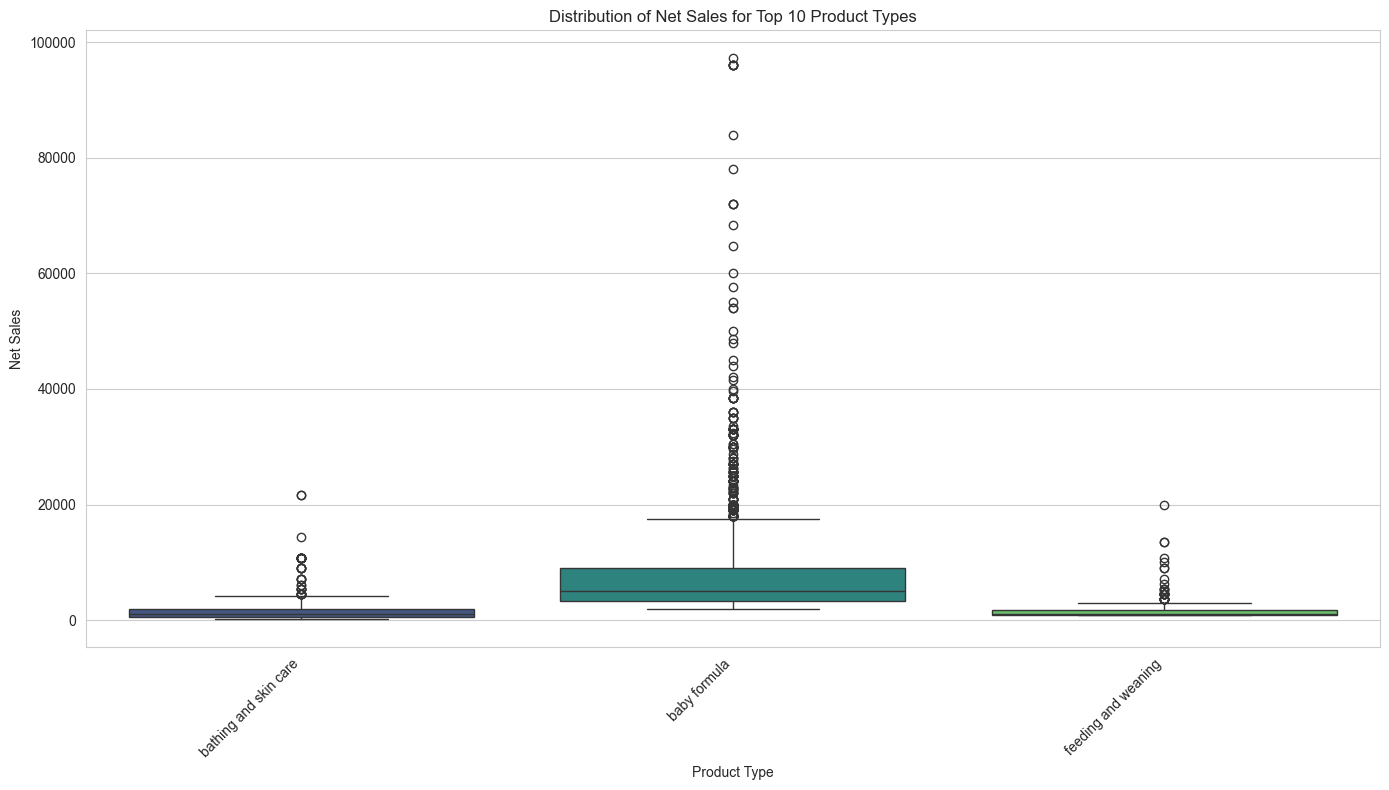

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a box plot to visualize the distribution of Net sales for each Product type
plt.figure(figsize=(14, 8))
sns.boxplot(x='Product type', y='Net sales', data=df, palette='viridis')
plt.title('Distribution of Net Sales for Top 10 Product Types')
plt.xlabel('Product Type')
plt.ylabel('Net Sales')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

#### Analyse sales and price trends for each product

In [226]:
#We first sort data chronologically
df = df.sort_values(by='Date').reset_index(drop=True)
print("DataFrame 'df' sorted by 'Date' column.")

DataFrame 'df' sorted by 'Date' column.


In [227]:
monthly_sales_trend = df.groupby(['Product', 'Year', 'Month'])['Net quantity'].sum().reset_index()
monthly_price_trend = df.groupby(['Product', 'Year', 'Month'])['unit_price'].mean().reset_index()


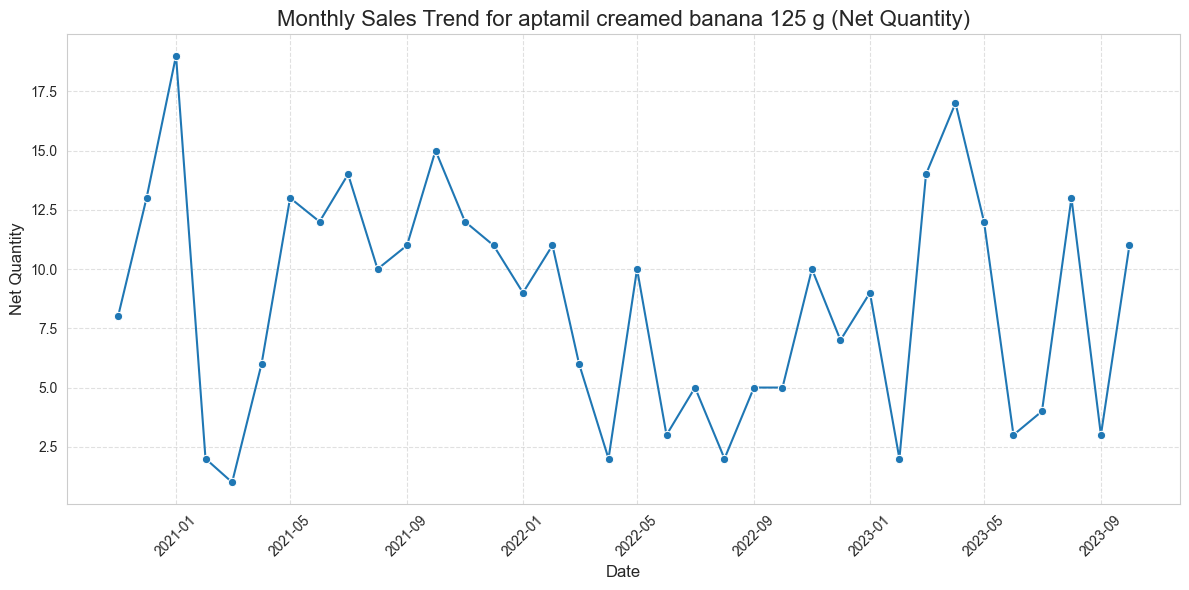

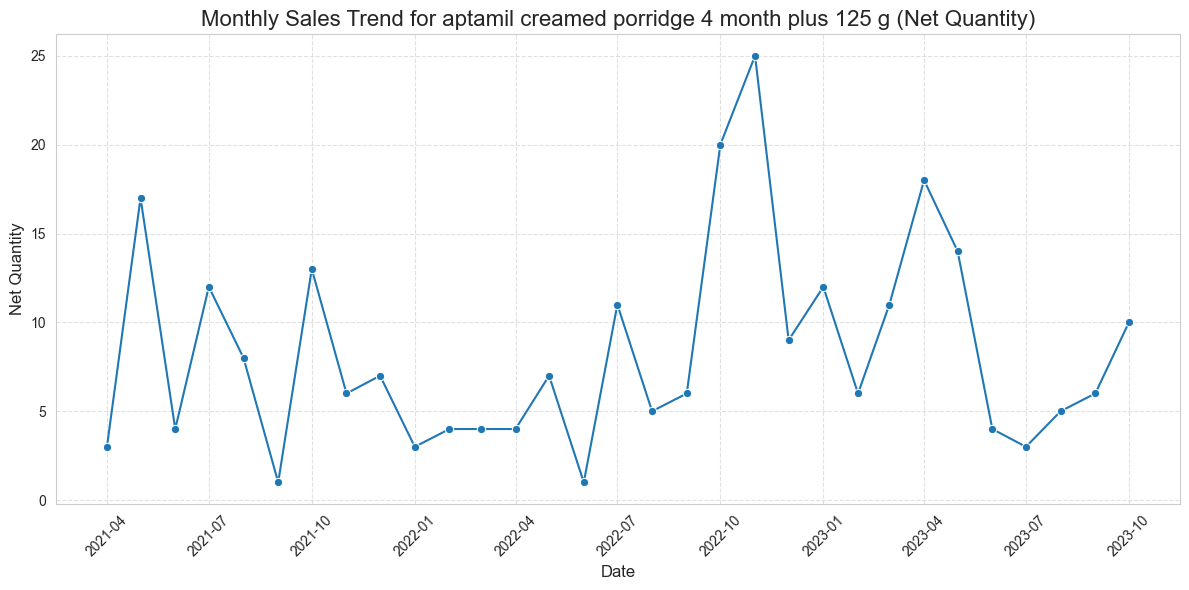

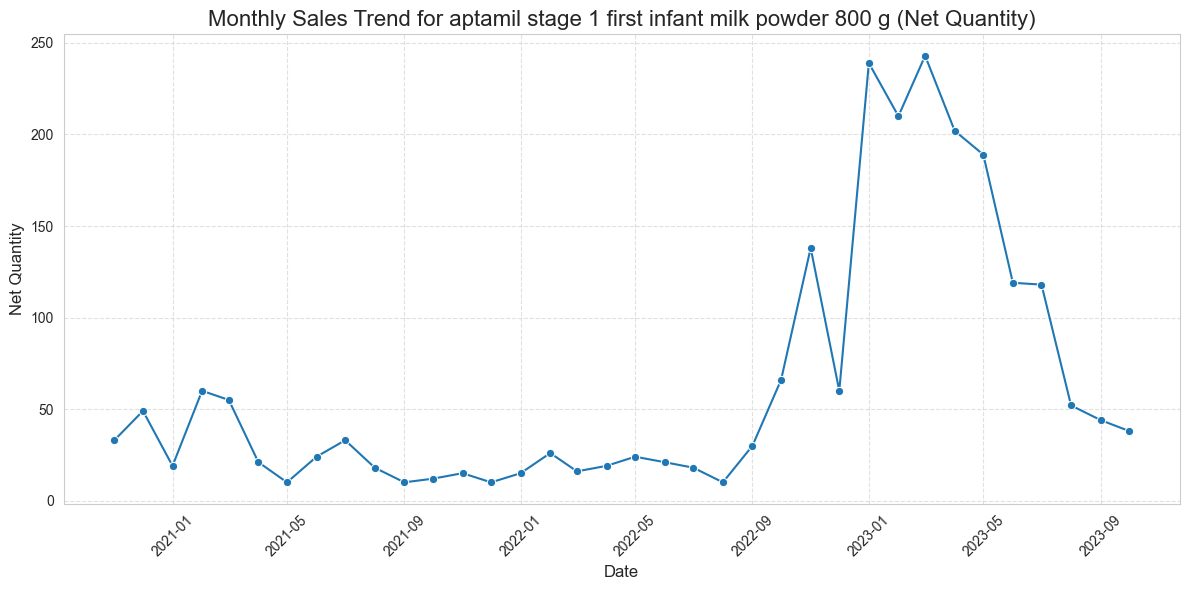

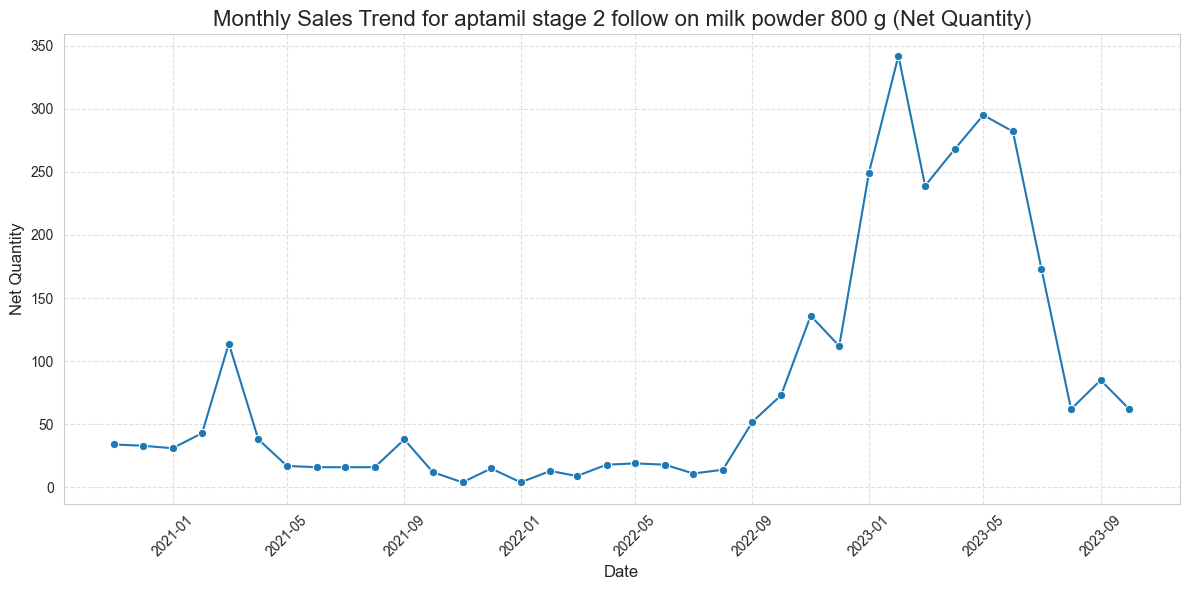

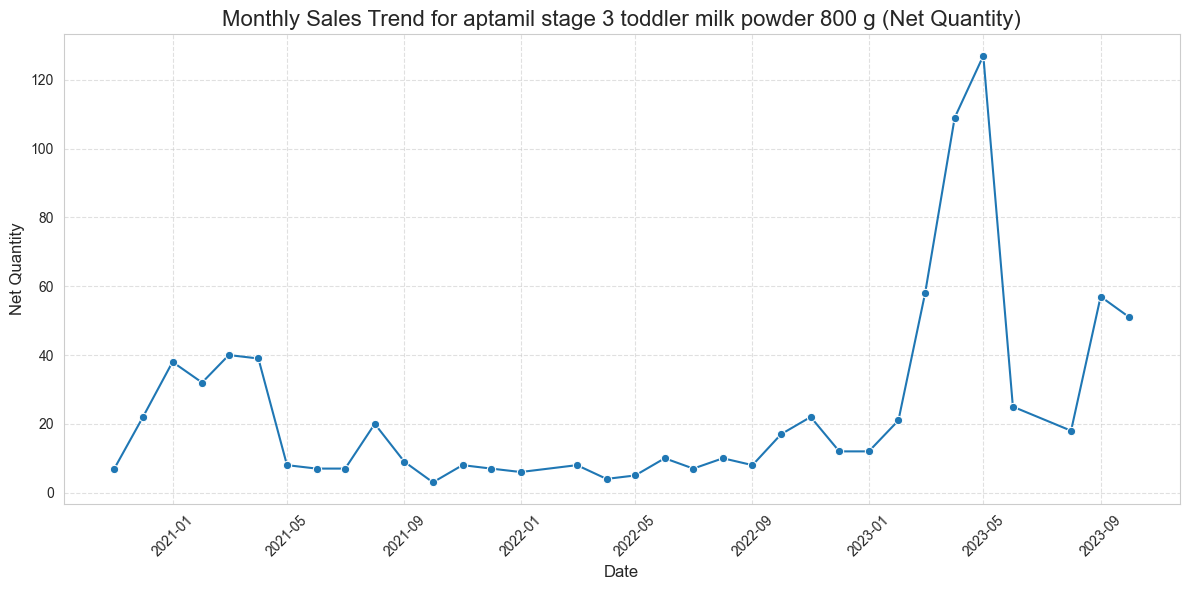

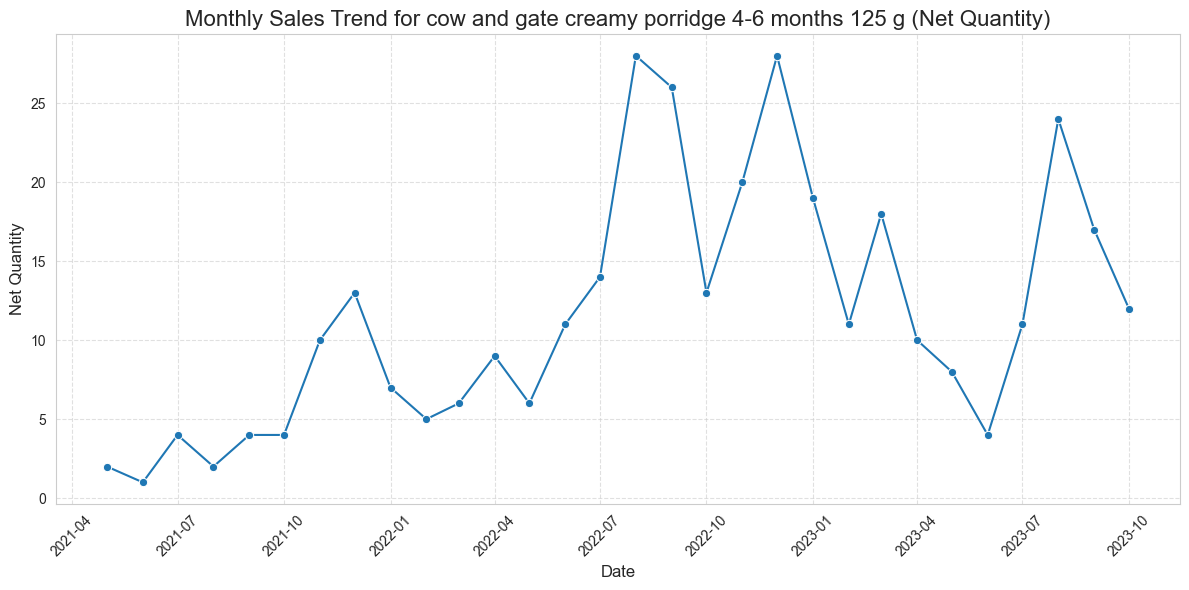

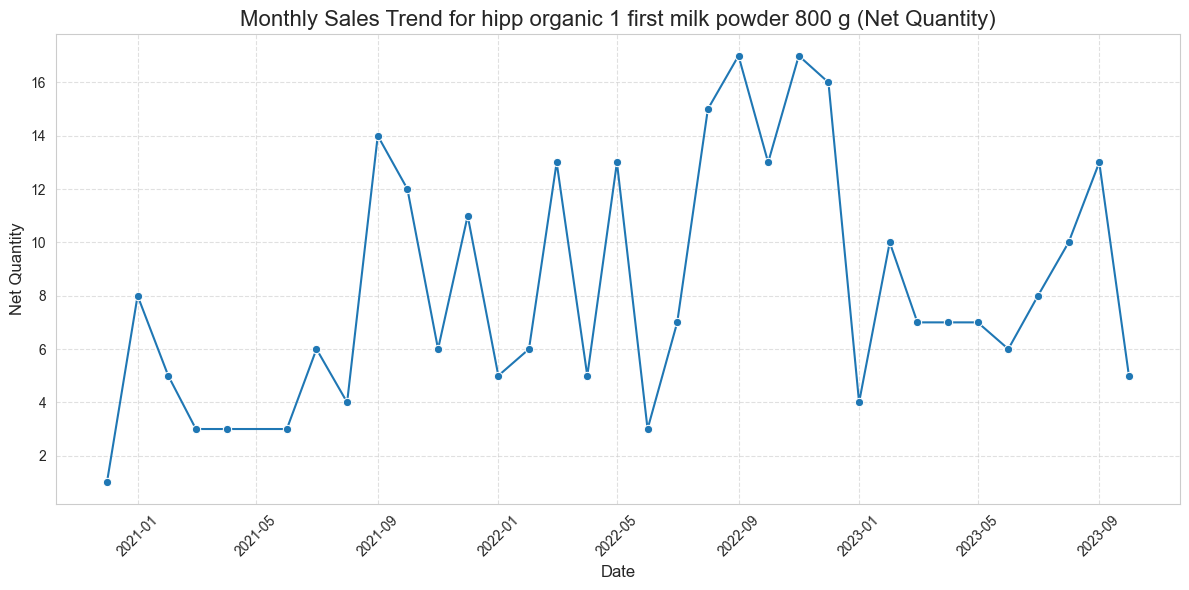

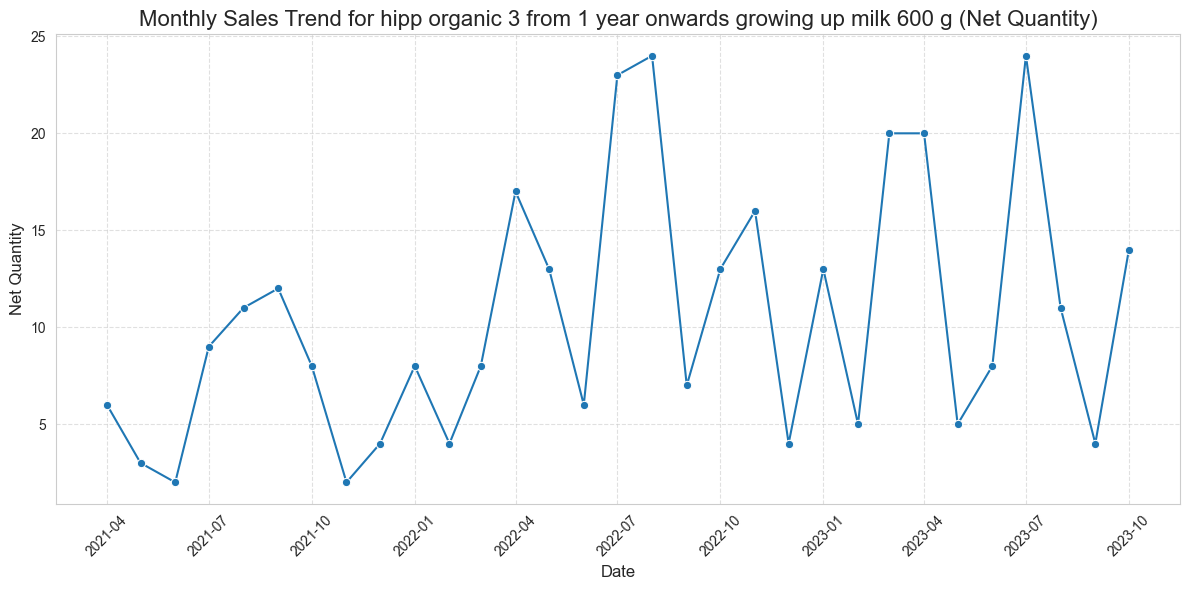

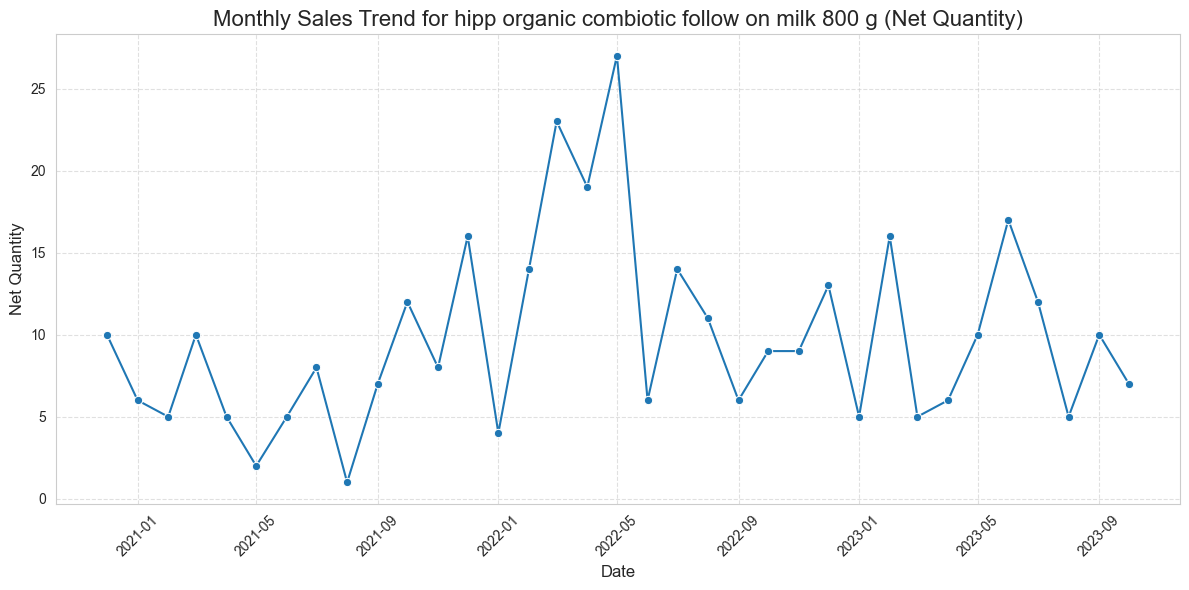

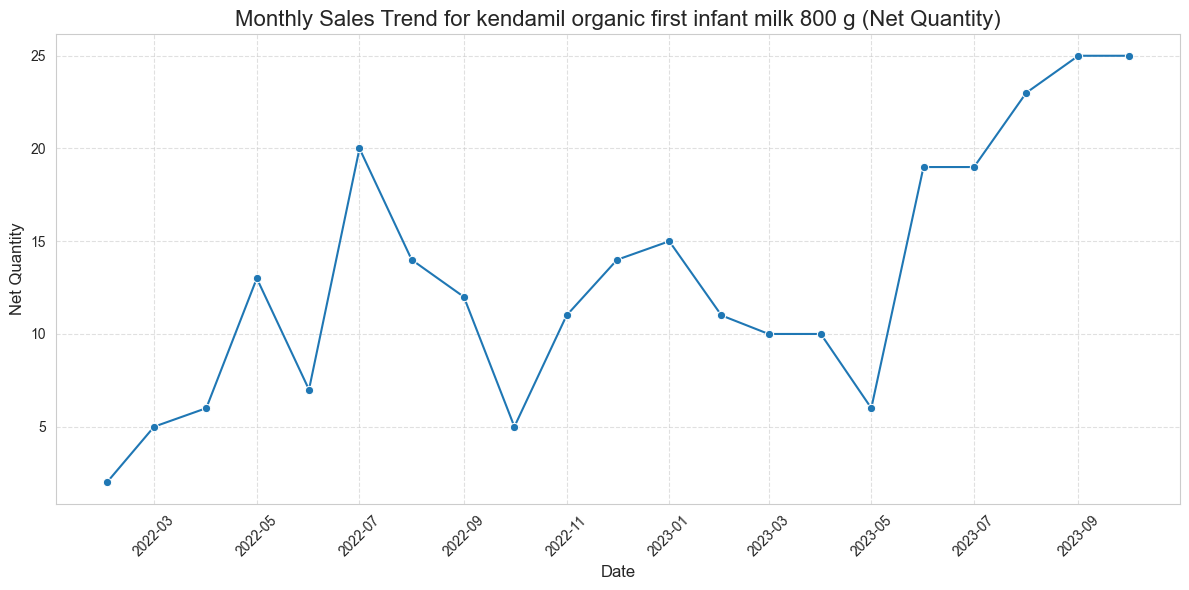

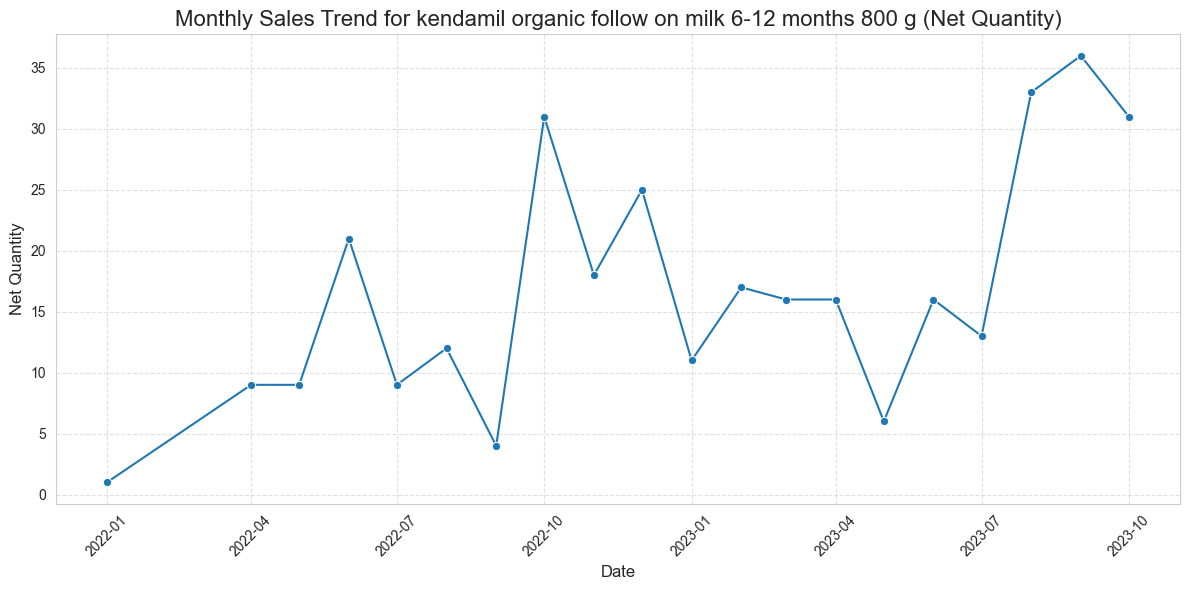

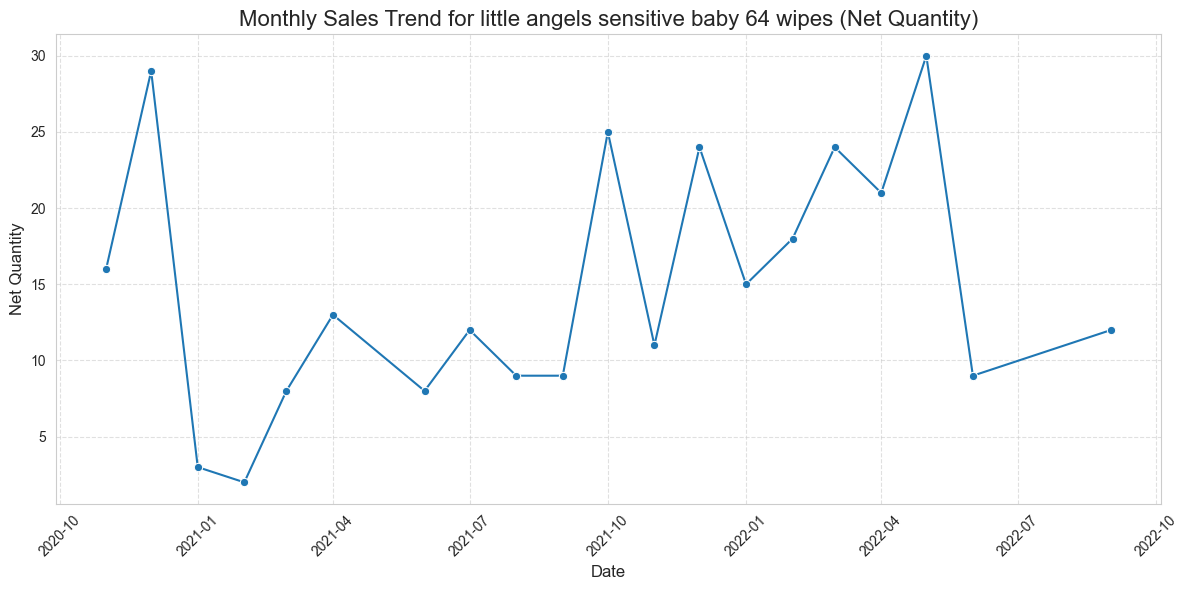

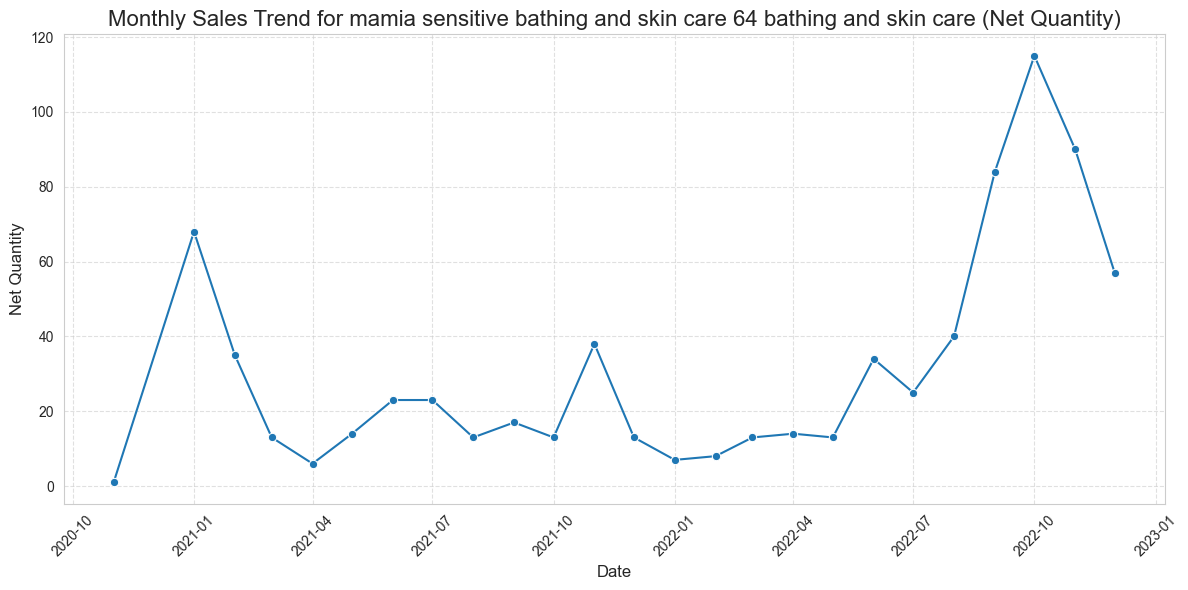

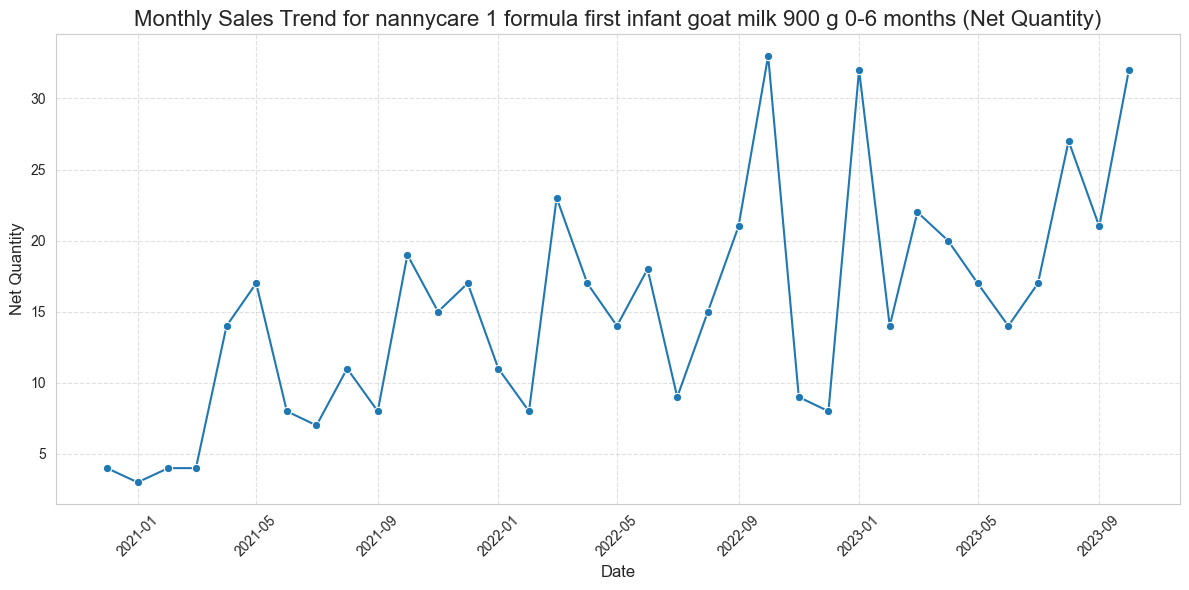

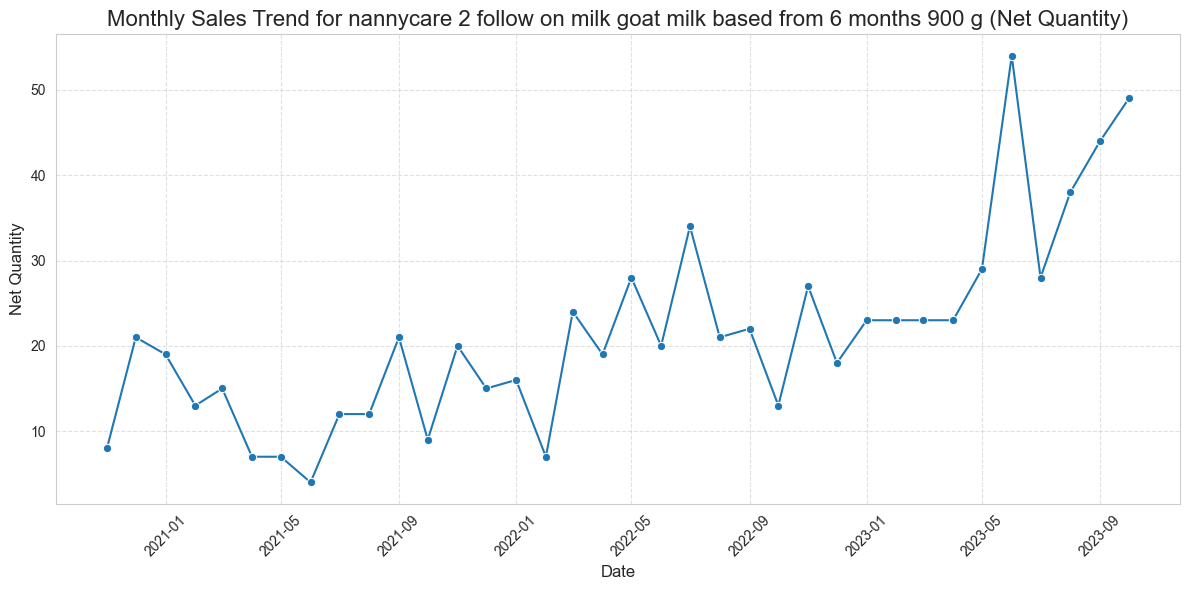

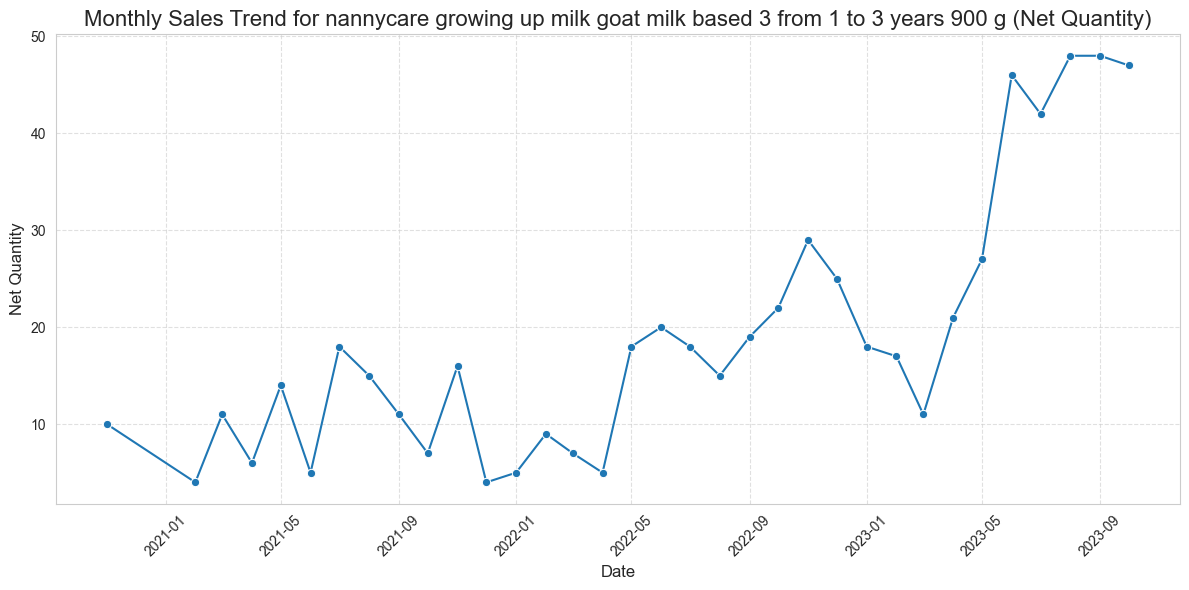

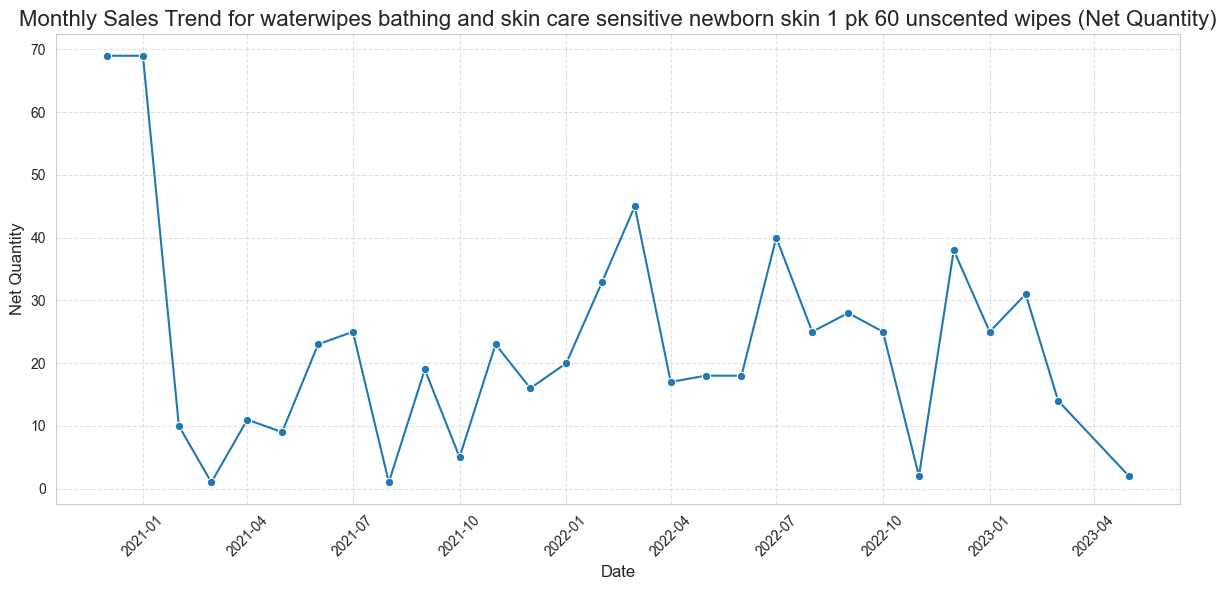

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 'Date_Month' column for easier plotting on the x-axis
monthly_sales_trend['Date_Month'] = pd.to_datetime(monthly_sales_trend['Year'].astype(str) + '-' + monthly_sales_trend['Month'].astype(str))

# Get unique product names
unique_products = monthly_sales_trend['Product'].unique()

# Plot individual product trends
for product in unique_products:
    plt.figure(figsize=(12, 6))
    product_data = monthly_sales_trend[monthly_sales_trend['Product'] == product]
    sns.lineplot(data=product_data, x='Date_Month', y='Net quantity', marker='o')
    plt.title(f'Monthly Sales Trend for {product} (Net Quantity)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Net Quantity', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

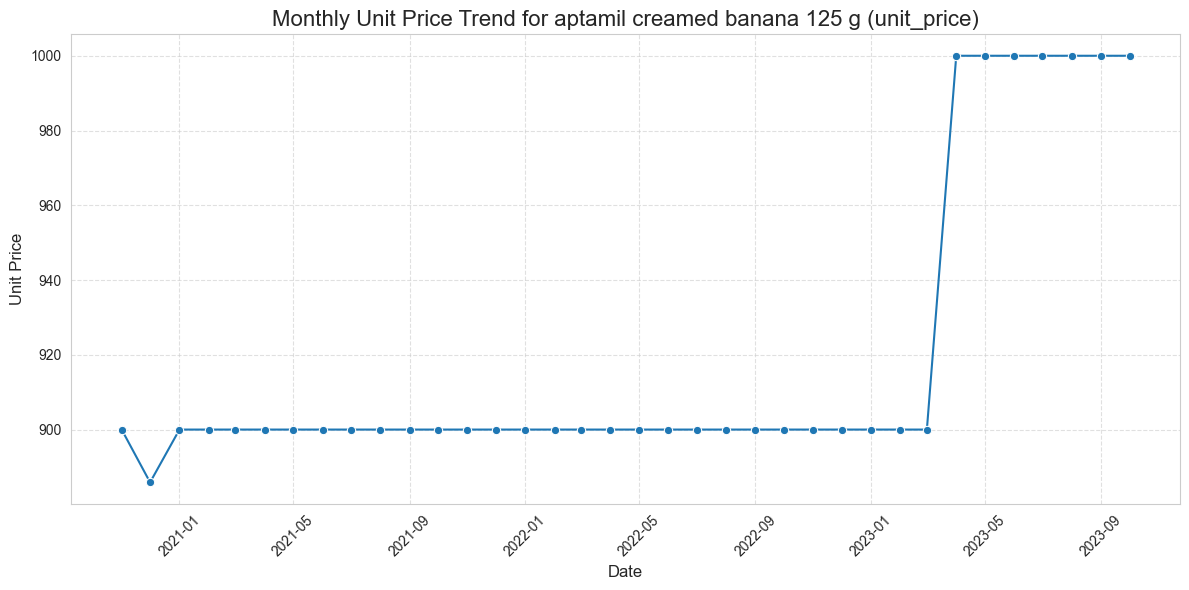

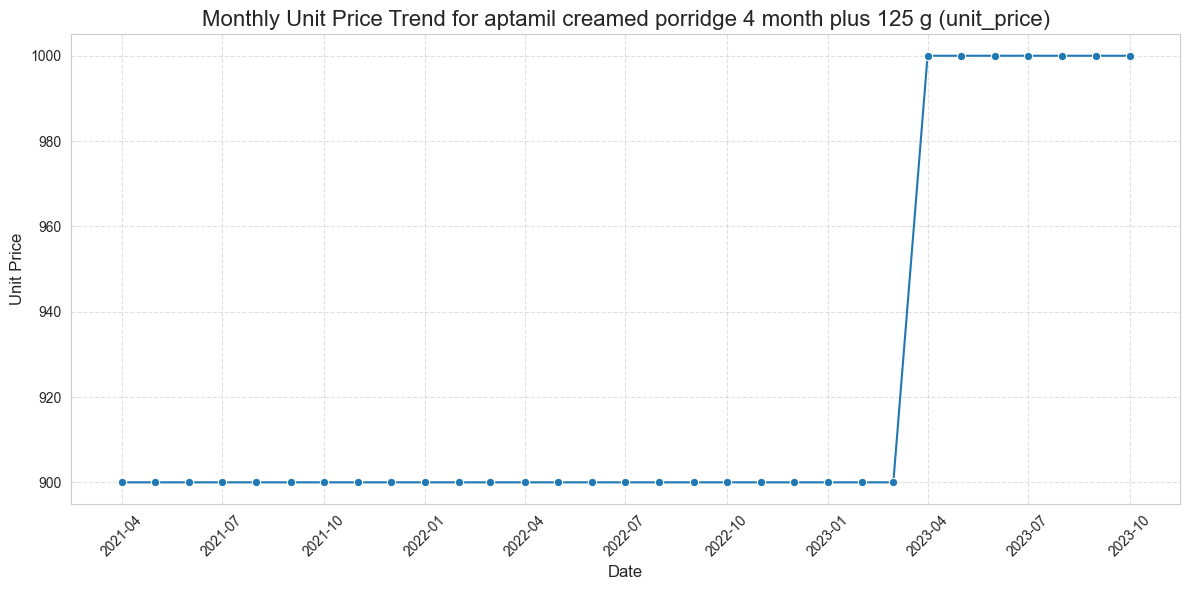

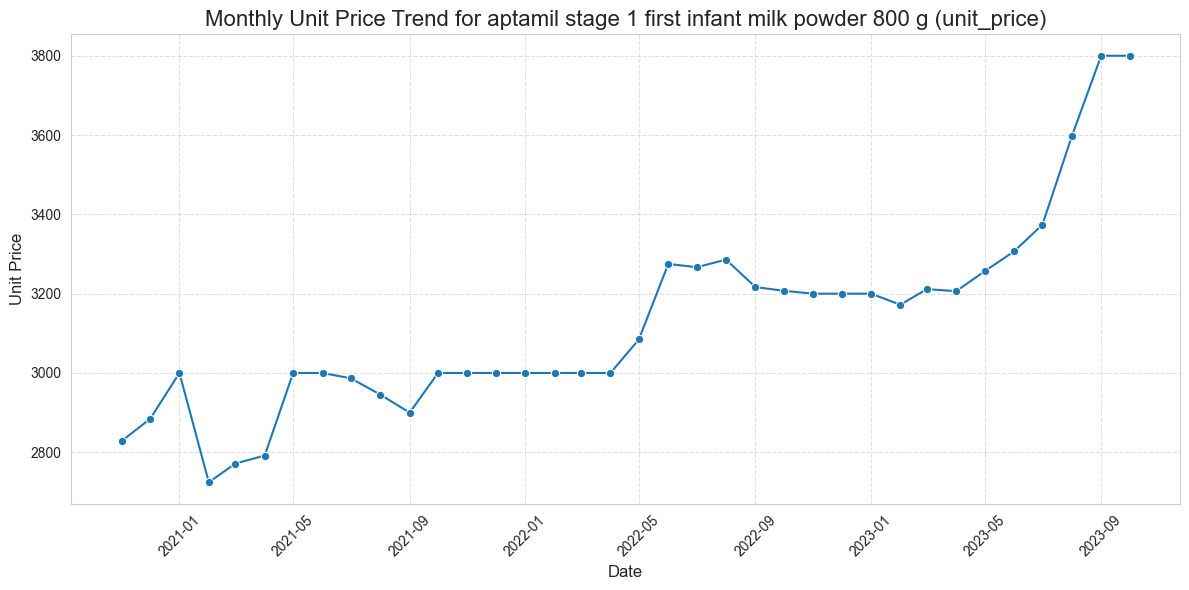

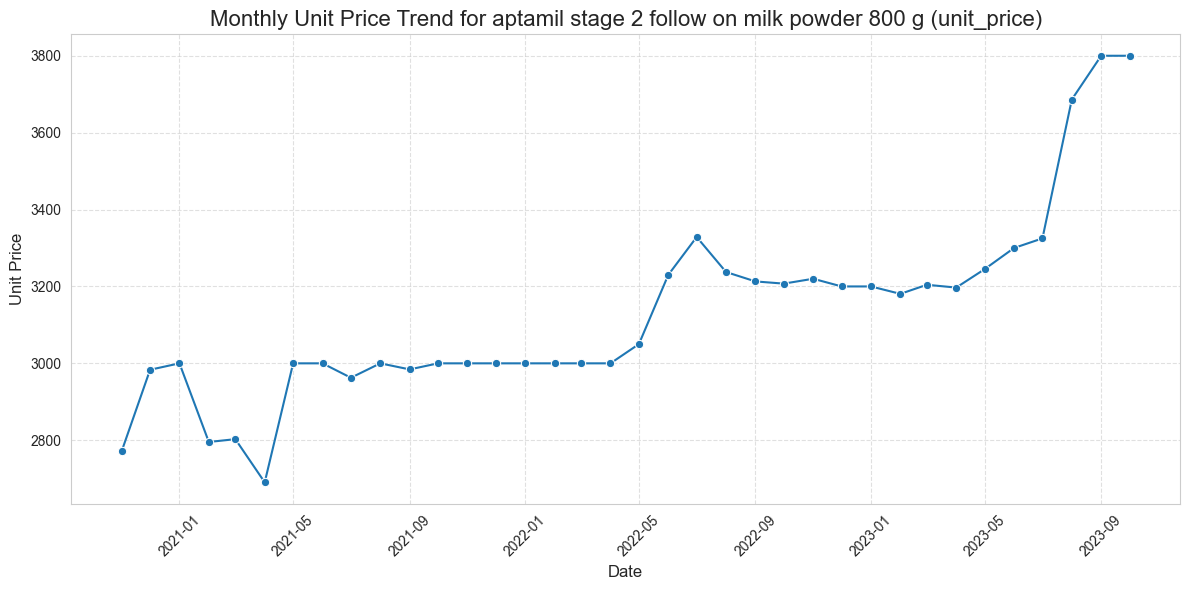

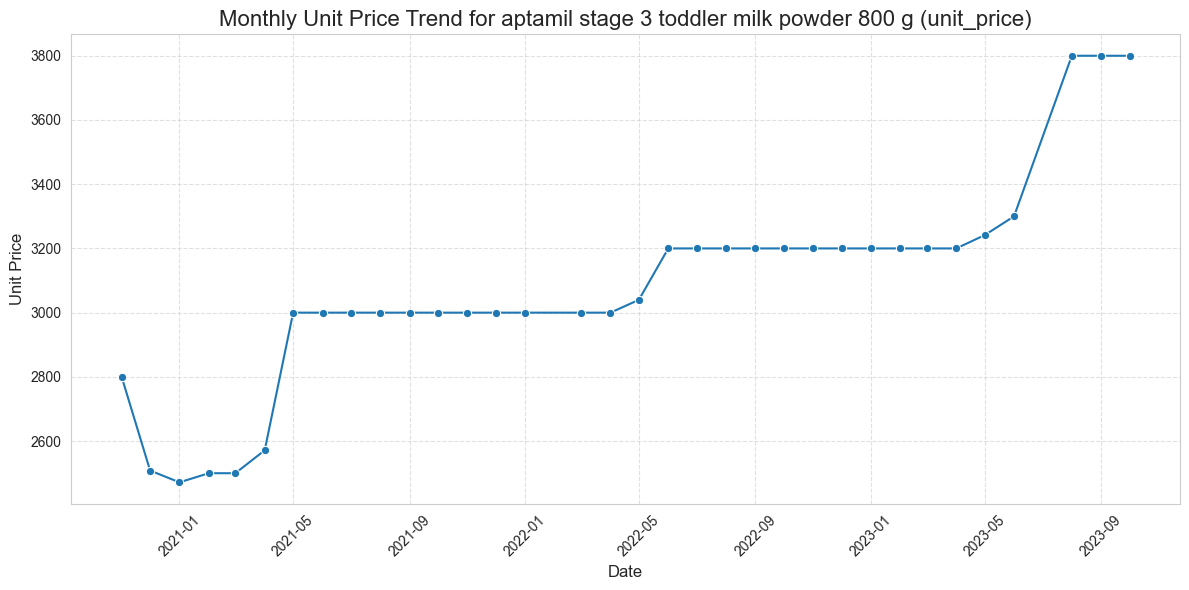

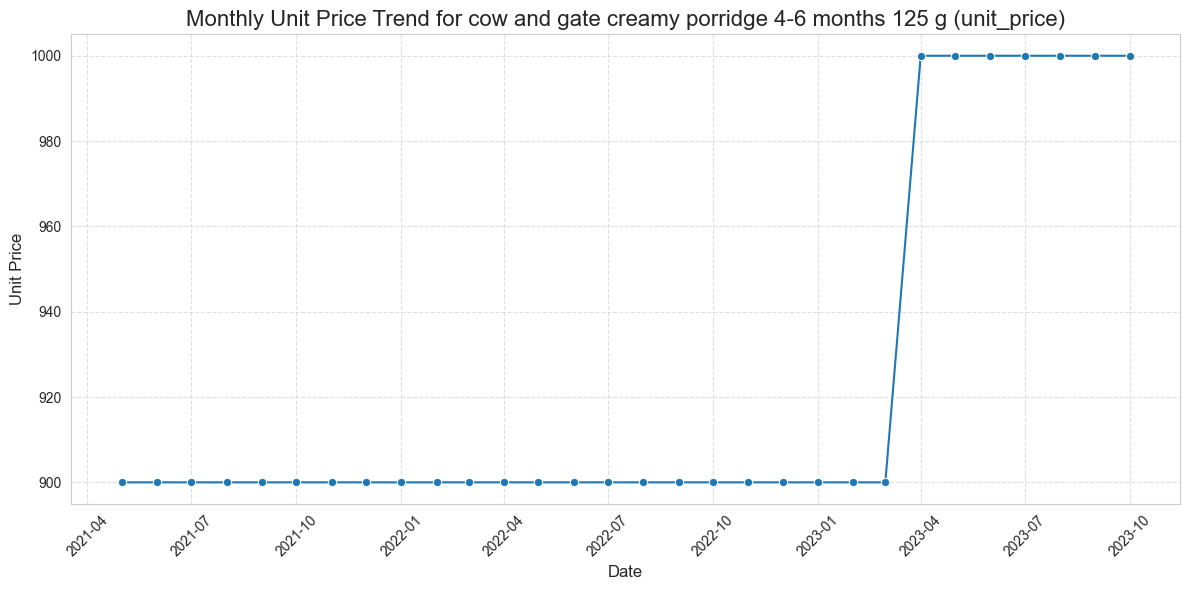

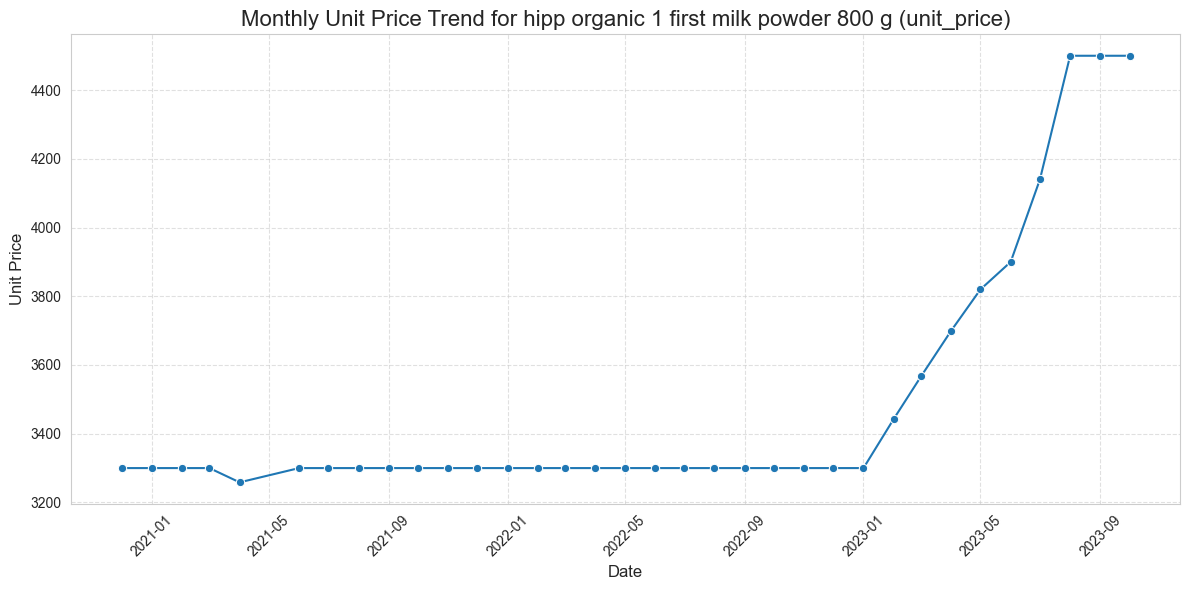

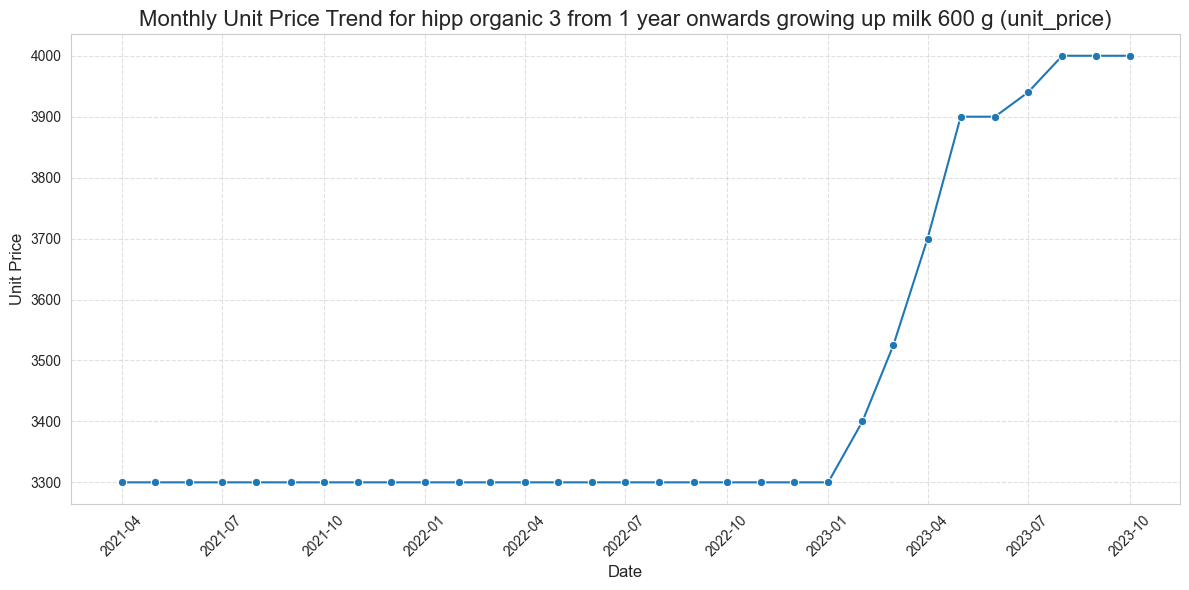

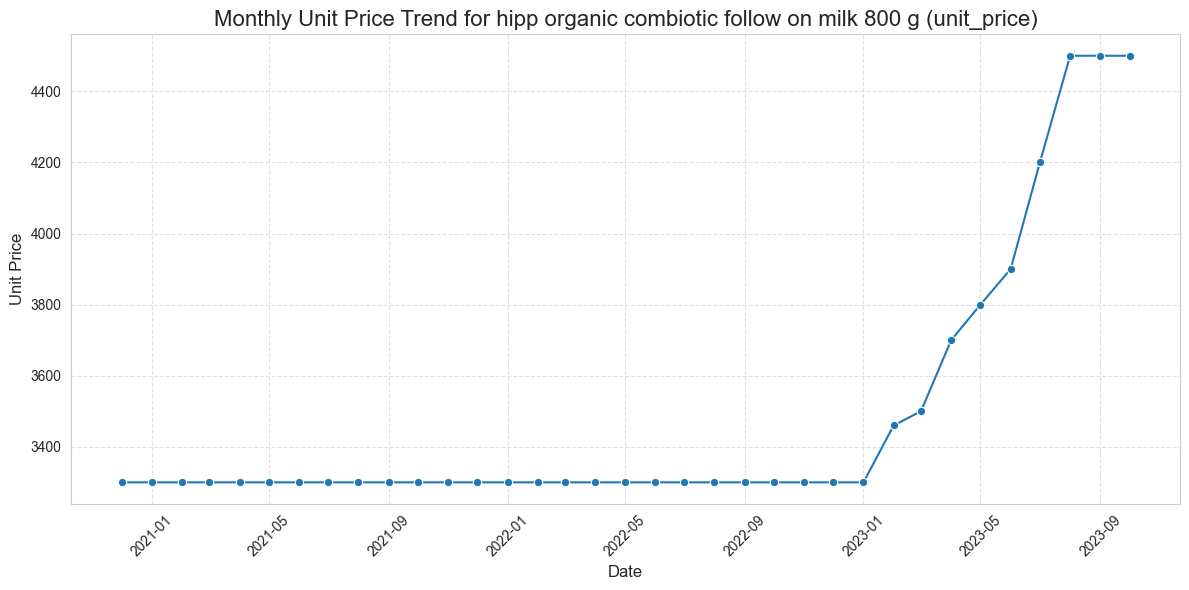

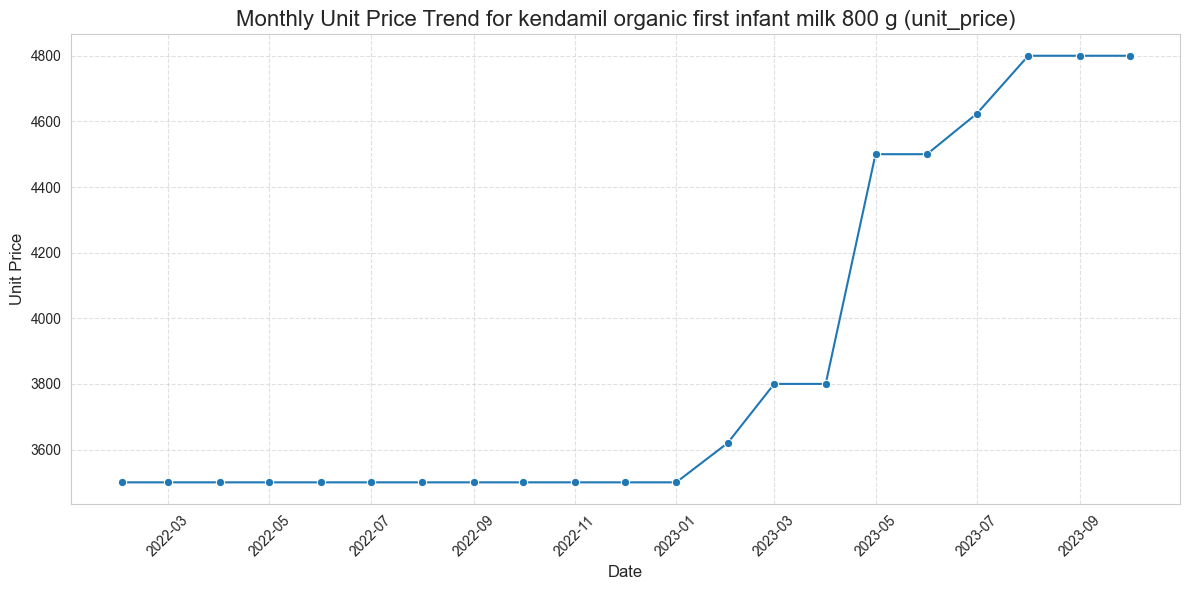

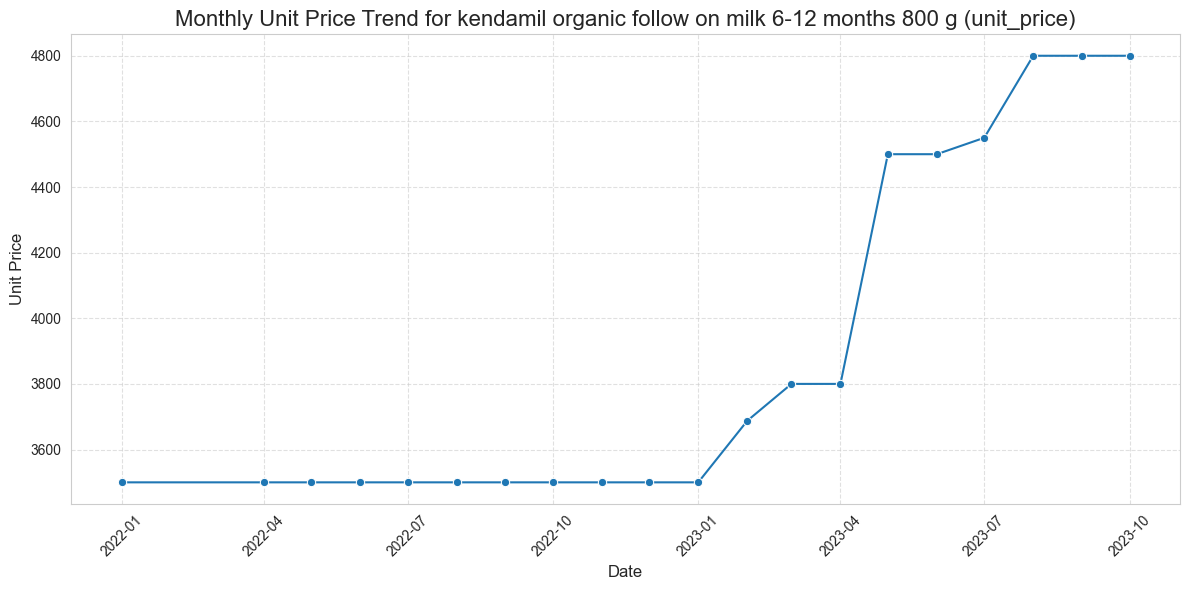

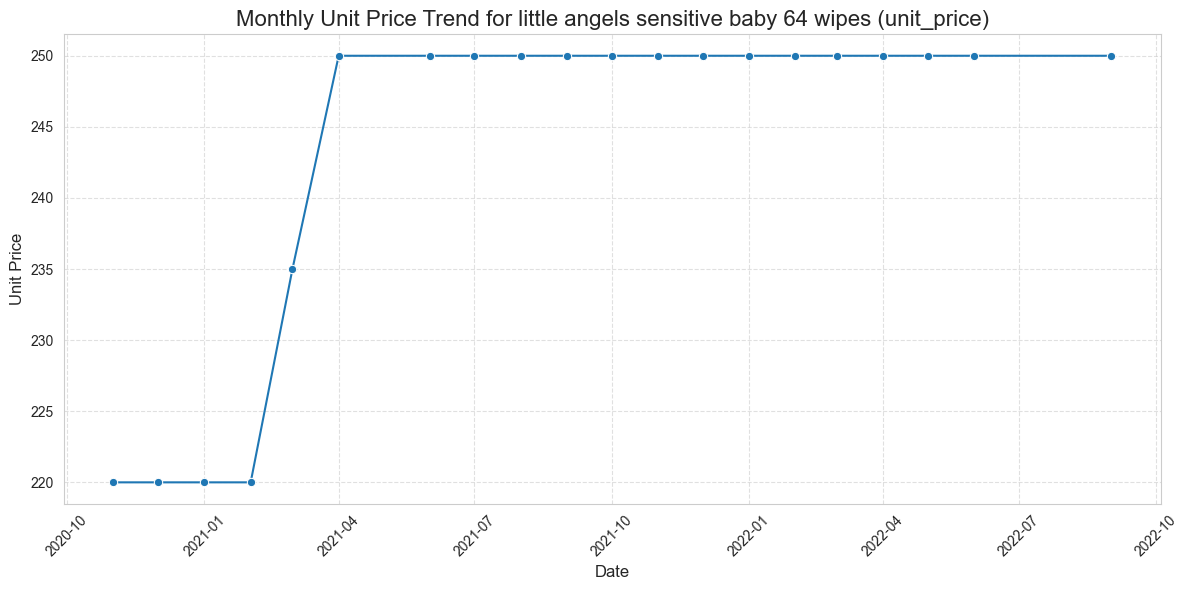

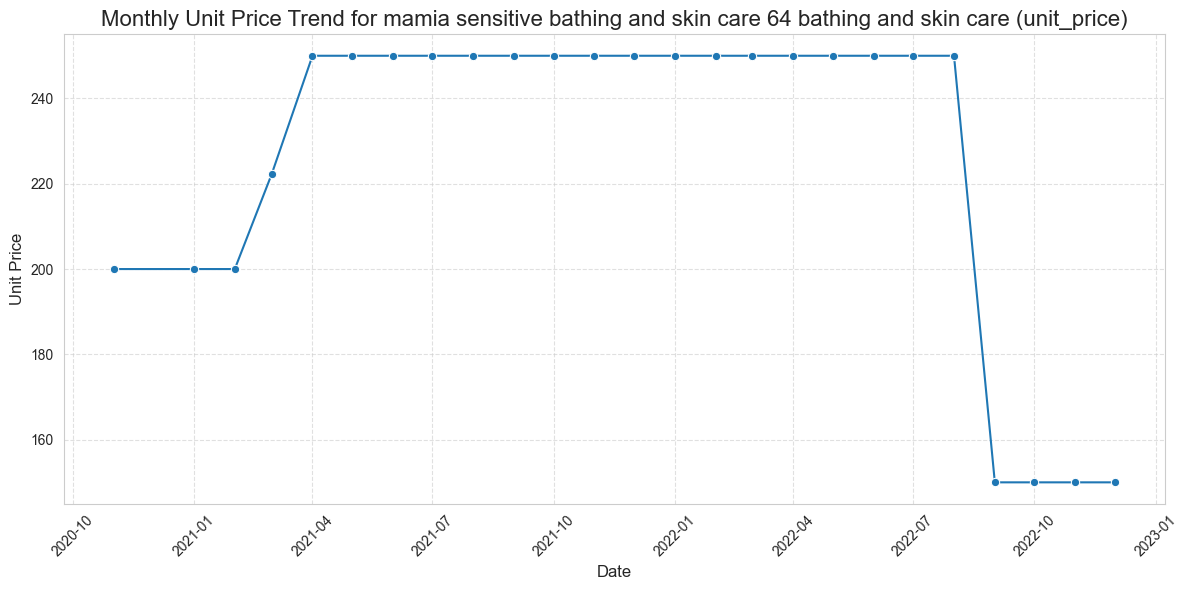

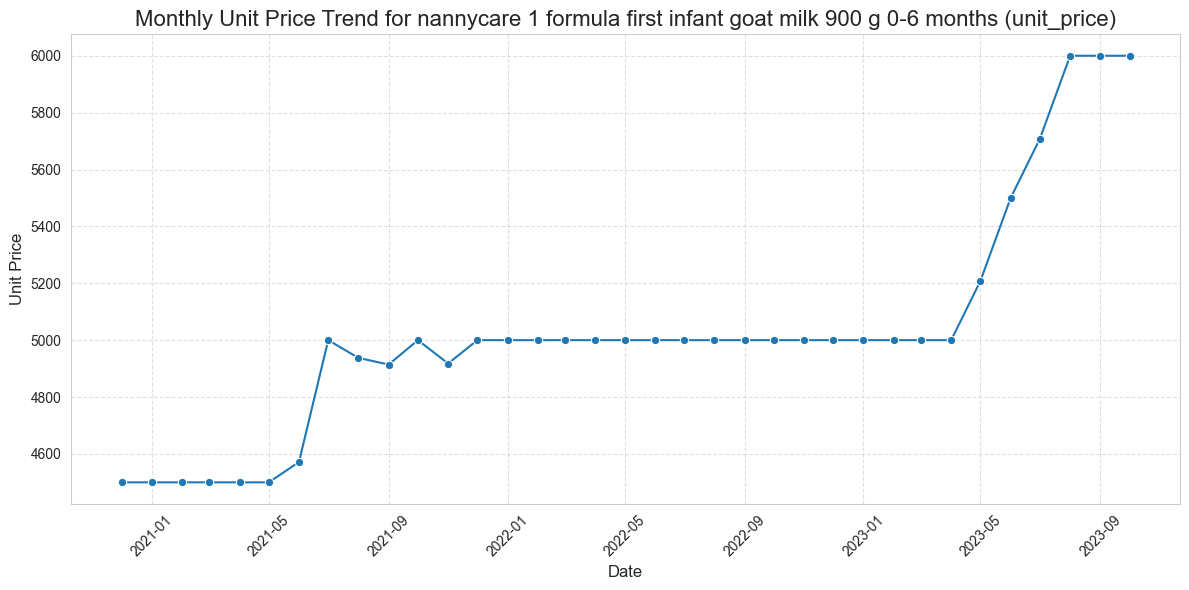

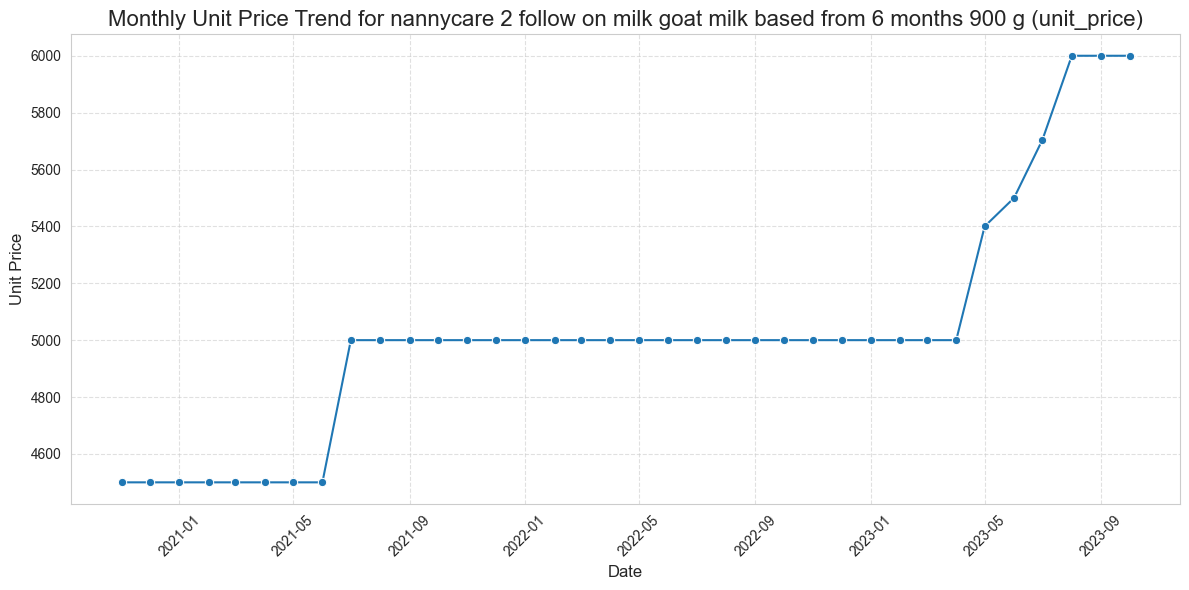

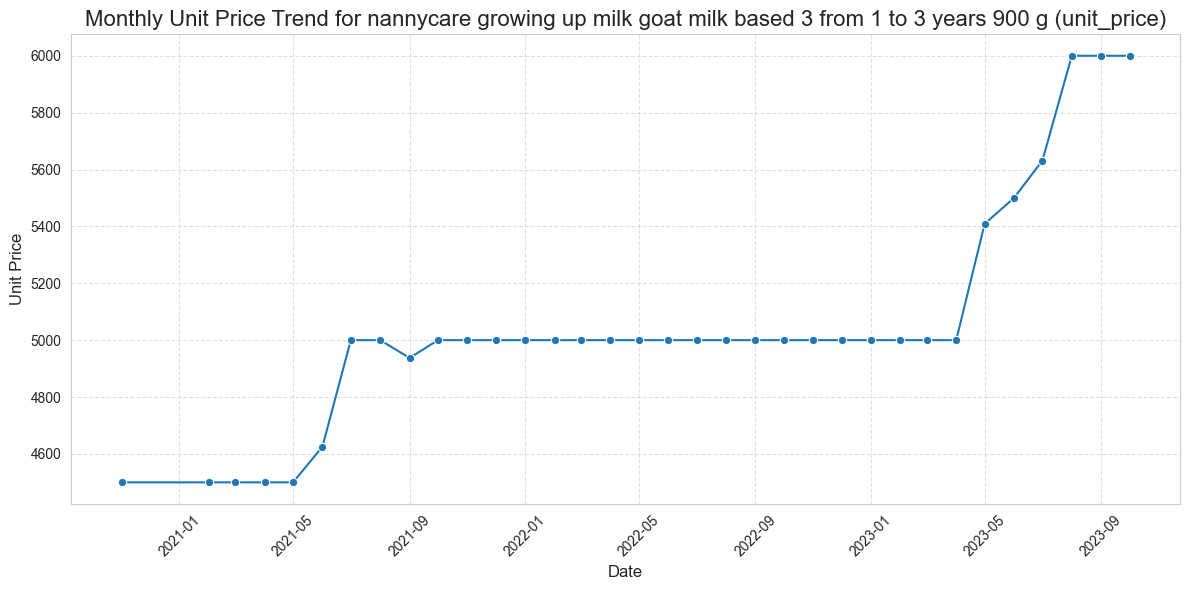

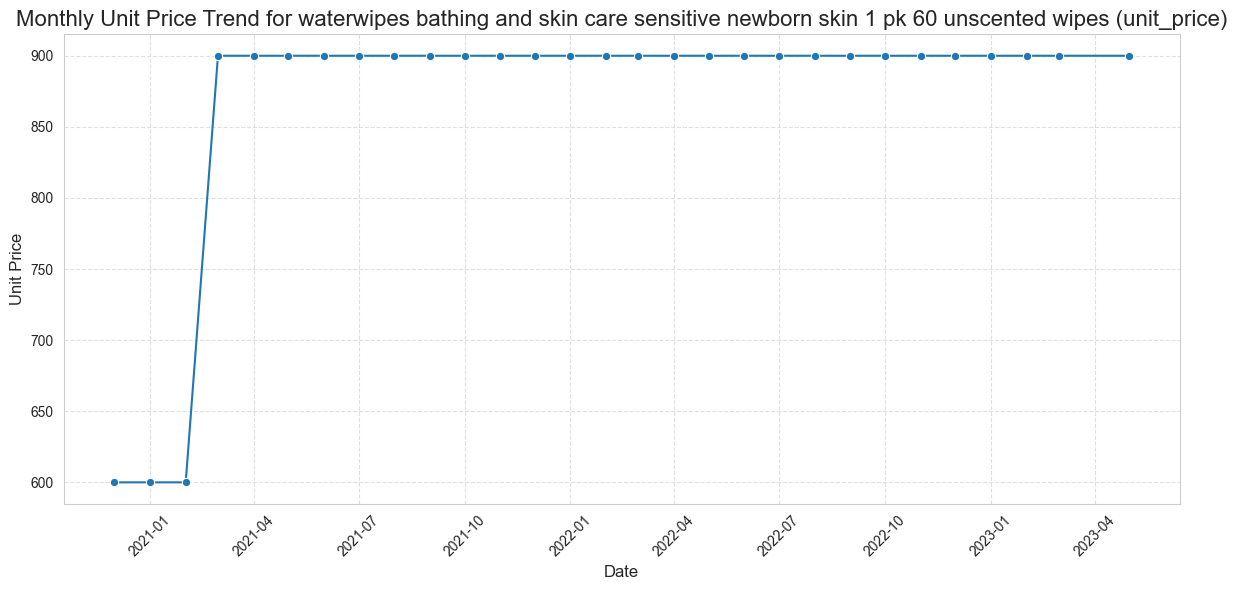

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 'Date_Month' column for easier plotting on the x-axis
monthly_price_trend['Date_Month'] = pd.to_datetime(monthly_price_trend['Year'].astype(str) + '-' + monthly_price_trend['Month'].astype(str))

# Get unique product names
unique_products = monthly_price_trend['Product'].unique()

# Plot individual product trends
for product in unique_products:
    plt.figure(figsize=(12, 6))
    product_data = monthly_price_trend[monthly_price_trend['Product'] == product]
    sns.lineplot(data=product_data, x='Date_Month', y='unit_price', marker='o')
    plt.title(f'Monthly Unit Price Trend for {product} (unit_price)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Unit Price', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

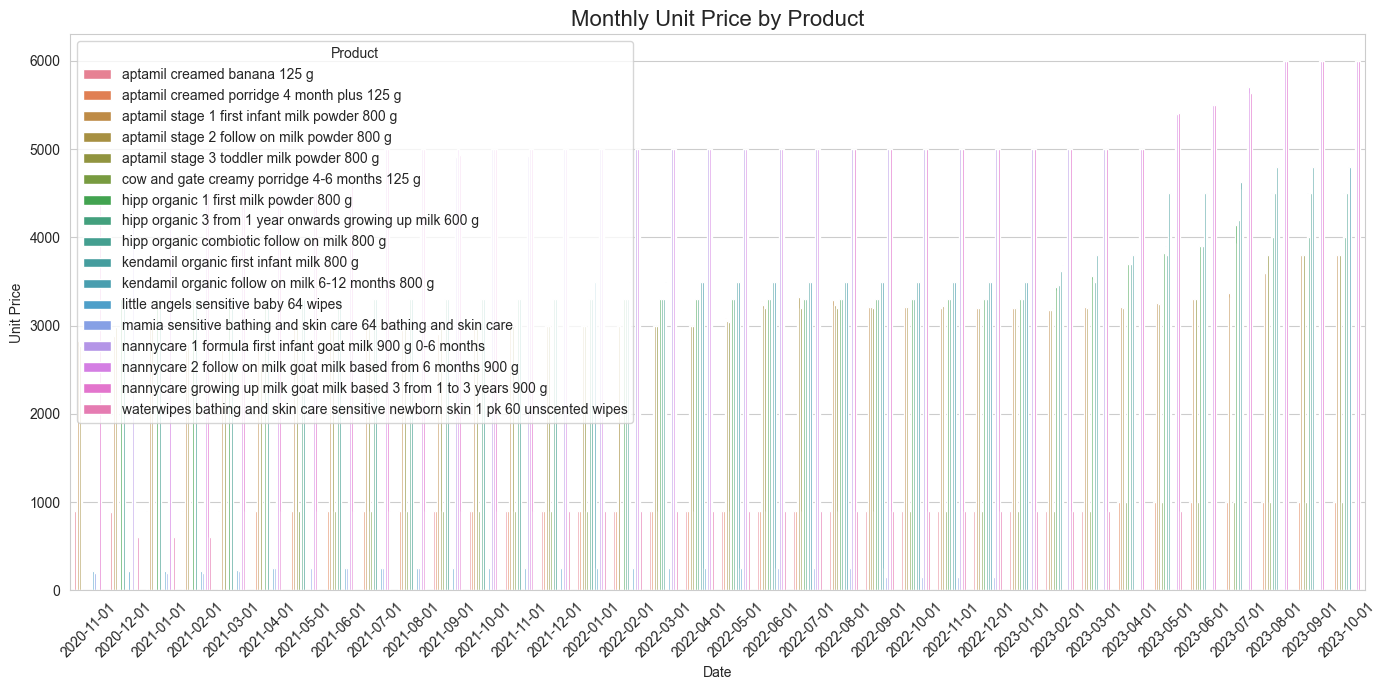

In [230]:
plt.figure(figsize=(14, 7))
sns.barplot(data=monthly_price_trend, x='Date_Month', y='unit_price', hue='Product')
plt.title('Monthly Unit Price by Product', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Unit Price')
plt.xticks(rotation=45)
plt.legend(title='Product')
plt.tight_layout()
plt.show()

In [231]:
print("Number of unique values per column:")
for column in df.columns:
    print(f"- {column}: {df[column].nunique()} unique values")

Number of unique values per column:
- Order ID: 5483 unique values
- Sale ID: 5853 unique values
- Date: 5482 unique values
- Sales channel: 2 unique values
- Product type: 3 unique values
- Product: 17 unique values
- Net quantity: 19 unique values
- Gross sales: 134 unique values
- Discounts: 38 unique values
- Net sales: 155 unique values
- Total sales: 155 unique values
- Month: 12 unique values
- Year: 4 unique values
- Weekday: 7 unique values
- unit_price: 43 unique values
- Discount_Percentage: 25 unique values


#### Feature Engineering for Demand Forecasting

In [232]:
#Date, Weekend, Week of year
df.loc[:, 'Day_of_Month'] = df['Date'].dt.day
#df.loc[:, 'Week_of_Year'] = df['Date'].dt.isocalendar().week.astype(int)
df.loc[:, 'Is_Weekend'] = df['Date'].dt.weekday.isin([5, 6])

#### Lagged Sales and rolling window for past sales to predict future

In [233]:
df['lag_1_net_quantity'] = df.groupby('Product')['Net quantity'].shift(1)
df['lag_2_net_quantity'] = df.groupby('Product')['Net quantity'].shift(2)
df['lag_3_net_quantity'] = df.groupby('Product')['Net quantity'].shift(3)

In [234]:
df.info()   


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   Order ID             5853 non-null   object                   
 1   Sale ID              5853 non-null   object                   
 2   Date                 5853 non-null   datetime64[ns, UTC+03:00]
 3   Sales channel        5853 non-null   object                   
 4   Product type         5853 non-null   object                   
 5   Product              5853 non-null   object                   
 6   Net quantity         5853 non-null   int64                    
 7   Gross sales          5853 non-null   float64                  
 8   Discounts            5853 non-null   float64                  
 9   Net sales            5853 non-null   float64                  
 10  Total sales          5853 non-null   float64                  
 11  Mont